In [3]:
import pandas as pd
import glob
import numpy as np


In [18]:
# --- 1) Load and combine CSV files --------------------------------------------------
# Find all CSVs matching the pattern (e.g., AOI01_bermdata_20250205.csv) in the folder.

file_paths = sorted(glob.glob('../data/gee-exports/AOI*_bermdata_20250205.csv'))

# Read each CSV into a DataFrame.
df_list = [pd.read_csv(fp) for fp in file_paths]

# Concatenate all AOI data into a single DataFrame (resetting the row index).
data = pd.concat(df_list, ignore_index=True)


# --- 2) MUKEY mapping dictionaries --------------------------------------------------
# These dicts translate MUKEY (soil map unit keys) to human-readable attributes.
# Note: MUKEYs are strings; keep keys as strings to avoid mismatches later.

MUKEY_to_mapunitname = {
    '53807': 'Glendale silt loam, 0 to 3 percent slopes',
    '53875': 'Riveroad and Comoro soils, 0 to 2 percent slopes',
    '53793': 'Diaspar sandy loam, 1 to 5 percent slopes',
    '53738': 'Altar-Sasabe complex, 1 to 8 percent slopes',
    '53806': 'Anthony fine sandy loam, 0 to 3 percent slopes',
    '53895': 'Bucklebar-Sahuarita complex, 0 to 3 percent slopes',
    '53886': 'Sasabe-Caralampi complex, 1 to 15 percent slopes',
    '53799': 'Glendale-Bucklebar complex, 0 to 3 percent slopes',
    '53759': 'Comoro sandy loam, 0 to 2 percent slopes'
}

MUKEY_to_slopeclass = {
    '53807': 'low', '53875': 'low', '53793': 'high', '53738': 'high',
    '53806': 'low', '53895': 'low', '53886': 'high', '53799': 'low', '53759': 'low'
}

MUKEY_to_landform = {
    '53807': 'Stream terraces', '53875': 'Flood plains', '53793': 'Fan terraces',
    '53738': 'Fan terraces', '53806': 'Flood plains', '53895': 'Fan terraces',
    '53886': 'Fan terraces, hills', '53799': 'Stream terraces', '53759': 'Flood plains'
}

MUKEY_to_parentmaterial = {
    '53807': 'Mixed alluvium',
    '53875': 'Moderately fine textured alluvium, Moderately coarse textured alluvium',
    '53793': 'Alluvium derived from granite and/or alluvium derived from schist',
    '53738': 'Alluvium derived from schist and/or alluvium derived from granite, Mixed alluvium',
    '53806': 'Mixed alluvium', '53895': 'Mixed alluvium', '53886': 'Mixed alluvium',
    '53799': 'Mixed alluvium', '53759': 'Mixed alluvium'
}

MUKEY_to_typicalprofile = {
    '53807': 'A-C', '53875': 'A-C, A-C1-C2-C3', '53793': 'A-Bt-2Bt-3BCt',
    '53738': 'A-Bw-BC-C, A-Bt1-Bt2-Bt3-2Btk', '53806': 'A-AC-C-Ck-C',
    '53895': 'A/Bt-Bt-Btk, A-Bk-2Btkb1-2Btkb2', '53886': 'A-Bt1-Bt2-Bt3-Btk, A-Bt1-Bt2-2C',
    '53799': 'A-C, A/Bt-Bt-Btk', '53759': 'A1-A2-C1-C2'
}

# --- 3) Standardize MUKEY and apply mappings ---------------------------------------
# Ensure MUKEY is string so dictionary lookups work even if the source was numeric.

data['MUKEY'] = data['MUKEY'].astype(str)

data['MapUnitName'] = data['MUKEY'].map(MUKEY_to_mapunitname)
data['SlopeClass'] = data['MUKEY'].map(MUKEY_to_slopeclass)
data['Landform'] = data['MUKEY'].map(MUKEY_to_landform)
data['ParentMaterial'] = data['MUKEY'].map(MUKEY_to_parentmaterial)
data['TypicalProfile'] = data['MUKEY'].map(MUKEY_to_typicalprofile)

# Harmonize landform label 
data['Landform'] = data['Landform'].replace({"Fan terraces, hills": "Fan terraces"})

# Check for unmatched MUKEYs 
# Inspect MUKEYs that did not find a match in the dictionaries—useful QA check.
unmatched_keys = data[data['MapUnitName'].isna()]['MUKEY'].unique()
print(f"Unmatched MUKEYs: {unmatched_keys}")

# --- 4) Classify berm condition -----------------------------------------------------
# Fill missing failure types as "Intact" and collapse to a binary condition:
# "Intact" vs "Degraded" (anything not exactly "Intact" is considered degraded).
data['Fail_Type'] = data['Fail_Type'].fillna("Intact")
data['Condition'] = data['Fail_Type'].apply(lambda x: 'Intact' if x == 'Intact' else 'Degraded')

# --- 5) Group and summarize ---------------------------------------------------------
# Count berms by Landform x Condition and display as a contingency table.
summary_counts = data.groupby(['Landform', 'Condition']).size().unstack(fill_value=0)
print("\nBerm Integrity Counts by Landform:\n")
print(summary_counts)

# Convert counts to within-landform proportions (rows sum to 1), rounded to 2 decimals.
summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
print("\nProportion of Berm Conditions by Landform:\n")
print(summary_proportions)

data['savi_background'] = data['savi_background'].replace(0, np.nan)


data['effect'] = (data['saviU_60'] - data['saviD_60']) / data['savi_background']
data['effect_percent'] = data['effect'] * 100



Unmatched MUKEYs: ['53844' '53897' '53817' '53855' '53744' '53820' '53899' '53849' '53757'
 '53902' '53907' '53865' '53826' '53846' '53822' '53756' '53788' '53783'
 '53901']

Berm Integrity Counts by Landform:

Condition        Degraded  Intact
Landform                         
Fan terraces           96      73
Flood plains          126     127
Stream terraces        53      88

Proportion of Berm Conditions by Landform:

Condition        Degraded  Intact
Landform                         
Fan terraces         0.57    0.43
Flood plains         0.50    0.50
Stream terraces      0.38    0.62


In [20]:
data.head().to_clipboard()

In [ ]:
# === Merge CSV points with shapefile features on lat/lon (exact) and via spatial nearest ===
# Requirements: geopandas, shapely, pandas

import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from shapely.strtree import STRtree

# --------------------- CONFIG ---------------------
# CSV_PATH = "../data/AOI1_bermdata_20250205.csv"
SHP_PATH = "../data/Berm_Directionality.shp"
OUTPUT_EXACT_CSV = "../data/merged_on_rounded_latlon.csv"
OUTPUT_NEAREST_GPKG = "../data/merged_spatial_nearest.gpkg"
OUTPUT_NEAREST_LAYER = "merged_nearest"
OUTPUT_NEAREST_GEOJSON = "../data/merged_spatial_nearest.geojson"
TOLERANCE_M = 50.0  # adjust if needed (e.g., 20, 100)
ROUND_NDP = 6       # rounding used for exact lat/lon merge
# ---------------------------------------------------

def _find_lat_lon(cols):
    lc = {c.lower(): c for c in cols}
    lat_candidates = ["lat", "latitude", "y", "lat_dd"]
    lon_candidates = ["lon", "long", "longitude", "x", "lon_dd"]
    lat_col = next((lc[c] for c in lat_candidates if c in lc), None)
    lon_col = next((lc[c] for c in lon_candidates if c in lc), None)
    return lat_col, lon_col

# 1) Load CSV and build point GeoDataFrame (WGS84)
csv = pd.read_csv(CSV_PATH)
csv_lat, csv_lon = _find_lat_lon(csv.columns)
if not csv_lat or not csv_lon:
    raise KeyError(f"Couldn't find lat/lon columns in CSV. Columns: {list(csv.columns)}")

gcsv = gpd.GeoDataFrame(
    csv.copy(),
    geometry=gpd.points_from_xy(csv[csv_lon], csv[csv_lat]),
    crs="EPSG:4326"
)

# 2) Load shapefile; ensure WGS84
gshp = gpd.read_file(SHP_PATH)
if gshp.crs is None:
    # assume WGS84 if CRS missing
    gshp.set_crs(epsg=4326, inplace=True)
elif gshp.crs.to_epsg() != 4326:
    gshp = gshp.to_crs(epsg=4326)

# ---------- A) Exact merge on rounded lat/lon (if shapefile has lat/lon columns) ----------
shp_lat, shp_lon = _find_lat_lon(gshp.columns)
exact_df = None
if shp_lat and shp_lon:
    def _key(df, lat_col, lon_col, ndp=ROUND_NDP):
        return (
            df[lat_col].astype(float).round(ndp).astype(str)
            + "_"
            + df[lon_col].astype(float).round(ndp).astype(str)
        )
    left = gcsv.copy()
    right = gshp.copy()
    left["__ll_key__"]  = _key(left,  csv_lat, csv_lon)
    right["__ll_key__"] = _key(right, shp_lat, shp_lon)

    exact_df = left.merge(
        right.drop(columns=["geometry"]),
        on="__ll_key__", how="left", suffixes=("", "_shp")
    ).drop(columns="__ll_key__")
    # Write out (optional)
    exact_df.to_csv(OUTPUT_EXACT_CSV, index=False)
    print(f"[Exact] wrote: {OUTPUT_EXACT_CSV} (rows={len(exact_df)})")
else:
    print("[Exact] shapefile has no obvious lat/lon fields; skipping exact rounded merge.")

# ---------- B) Spatial nearest join within tolerance (robust) ----------
# Project to metric CRS for distances (use EPSG:3857; for best accuracy choose a local UTM if known)
gcsv_m = gcsv.to_crs(epsg=3857)
gshp_m = gshp.to_crs(epsg=3857)

# Build STRtree on shapefile geometries
right_geoms = list(gshp_m.geometry)
tree = STRtree(right_geoms)
id_map = {id(geom): i for i, geom in enumerate(right_geoms)}

nearest_idx = []
nearest_dist = []

for pt in gcsv_m.geometry:
    if pt is None or pt.is_empty:
        nearest_idx.append(None)
        nearest_dist.append(float("nan"))
        continue
    cand = tree.nearest(pt)       # nearest geometry
    idx = id_map.get(id(cand), None)
    d = pt.distance(cand) if idx is not None else float("nan")
    if idx is not None and d <= TOLERANCE_M:
        nearest_idx.append(idx)
        nearest_dist.append(d)
    else:
        nearest_idx.append(None)
        nearest_dist.append(d)

left_df = gcsv_m.reset_index(drop=True).copy()
right_df = gshp_m.reset_index(drop=True).copy()

left_df["__nearest_idx__"] = nearest_idx
left_df["dist_m"] = nearest_dist

# Keep only those within tolerance
joined = left_df[left_df["__nearest_idx__"].notna()].copy()
joined = joined.merge(
    right_df.drop(columns=["geometry"]),
    left_on="__nearest_idx__", right_index=True, how="left", suffixes=("", "_shp")
).drop(columns="__nearest_idx__")

# Back to WGS84 and save
joined = gpd.GeoDataFrame(joined, geometry="geometry", crs="EPSG:3857").to_crs(epsg=4326)
joined.to_file(OUTPUT_NEAREST_GPKG, layer=OUTPUT_NEAREST_LAYER, driver="GPKG")
joined.to_file(OUTPUT_NEAREST_GEOJSON, driver="GeoJSON")

print(f"[Nearest] wrote: {OUTPUT_NEAREST_GPKG} (layer={OUTPUT_NEAREST_LAYER}, rows={len(joined)})")
print(f"[Nearest] wrote: {OUTPUT_NEAREST_GEOJSON} (rows={len(joined)})")

# ---------- Quick peek ----------
print("\nPreview (nearest-join):")
display_cols = [c for c in ["dist_m","id","Type","Direction","berm_angle","AOI",csv_lat,csv_lon] if c in joined.columns]
print(joined[display_cols].head(10))


In [13]:
data['Fail_Type'] = data['Fail_Type'].replace("No fail", "Intact")
data['Landform'] = data['Landform'].replace({"Fan terraces": "Fan terraces, hills"})

# Define landform stability
data['landform_stability'] = data['Landform'].replace({
    'Fan terraces, hills': 'Stable',
    'Stream terraces': 'Stable',
    'Flood plains': 'Unstable'
})

# Define berm length category
data = data.dropna(subset=['Shape_Leng', 'Fail_Type', 'landform_stability'])
data['Berm_Length_Class'] = data['Shape_Leng'].apply(
    lambda x: 'Short (≤ 50 m)' if x <= 50 else 'Long (> 50 m)'
)


# Bin slope
data['Slope_Class'] = data['slope_100'].apply(
    lambda x: "Shallow (≤ 2%)" if x <= 2 else "Steep (> 2%)"
)

data['Soil_Development'] = data['TypicalProfile'].apply(
    lambda x: 'B horizon' if 'B' in x else 'No B horizon'
)


In [14]:
 data['TypicalProfile'].unique()

array(['A-C, A/Bt-Bt-Btk', 'A-C', 'A/Bt-Bt-Btk, A-Bk-2Btkb1-2Btkb2',
       'A-AC-C-Ck-C', 'A-Bt-2Bt-3BCt', 'A1-A2-C1-C2',
       'A-Bt1-Bt2-Bt3-Btk, A-Bt1-Bt2-2C', 'A-C, A-C1-C2-C3',
       'A-Bw-BC-C, A-Bt1-Bt2-Bt3-2Btk'], dtype=object)

In [11]:
data['Landform'].unique()

array(['Stream terraces', 'Fan terraces, hills', 'Flood plains'],
      dtype=object)

<Axes: >

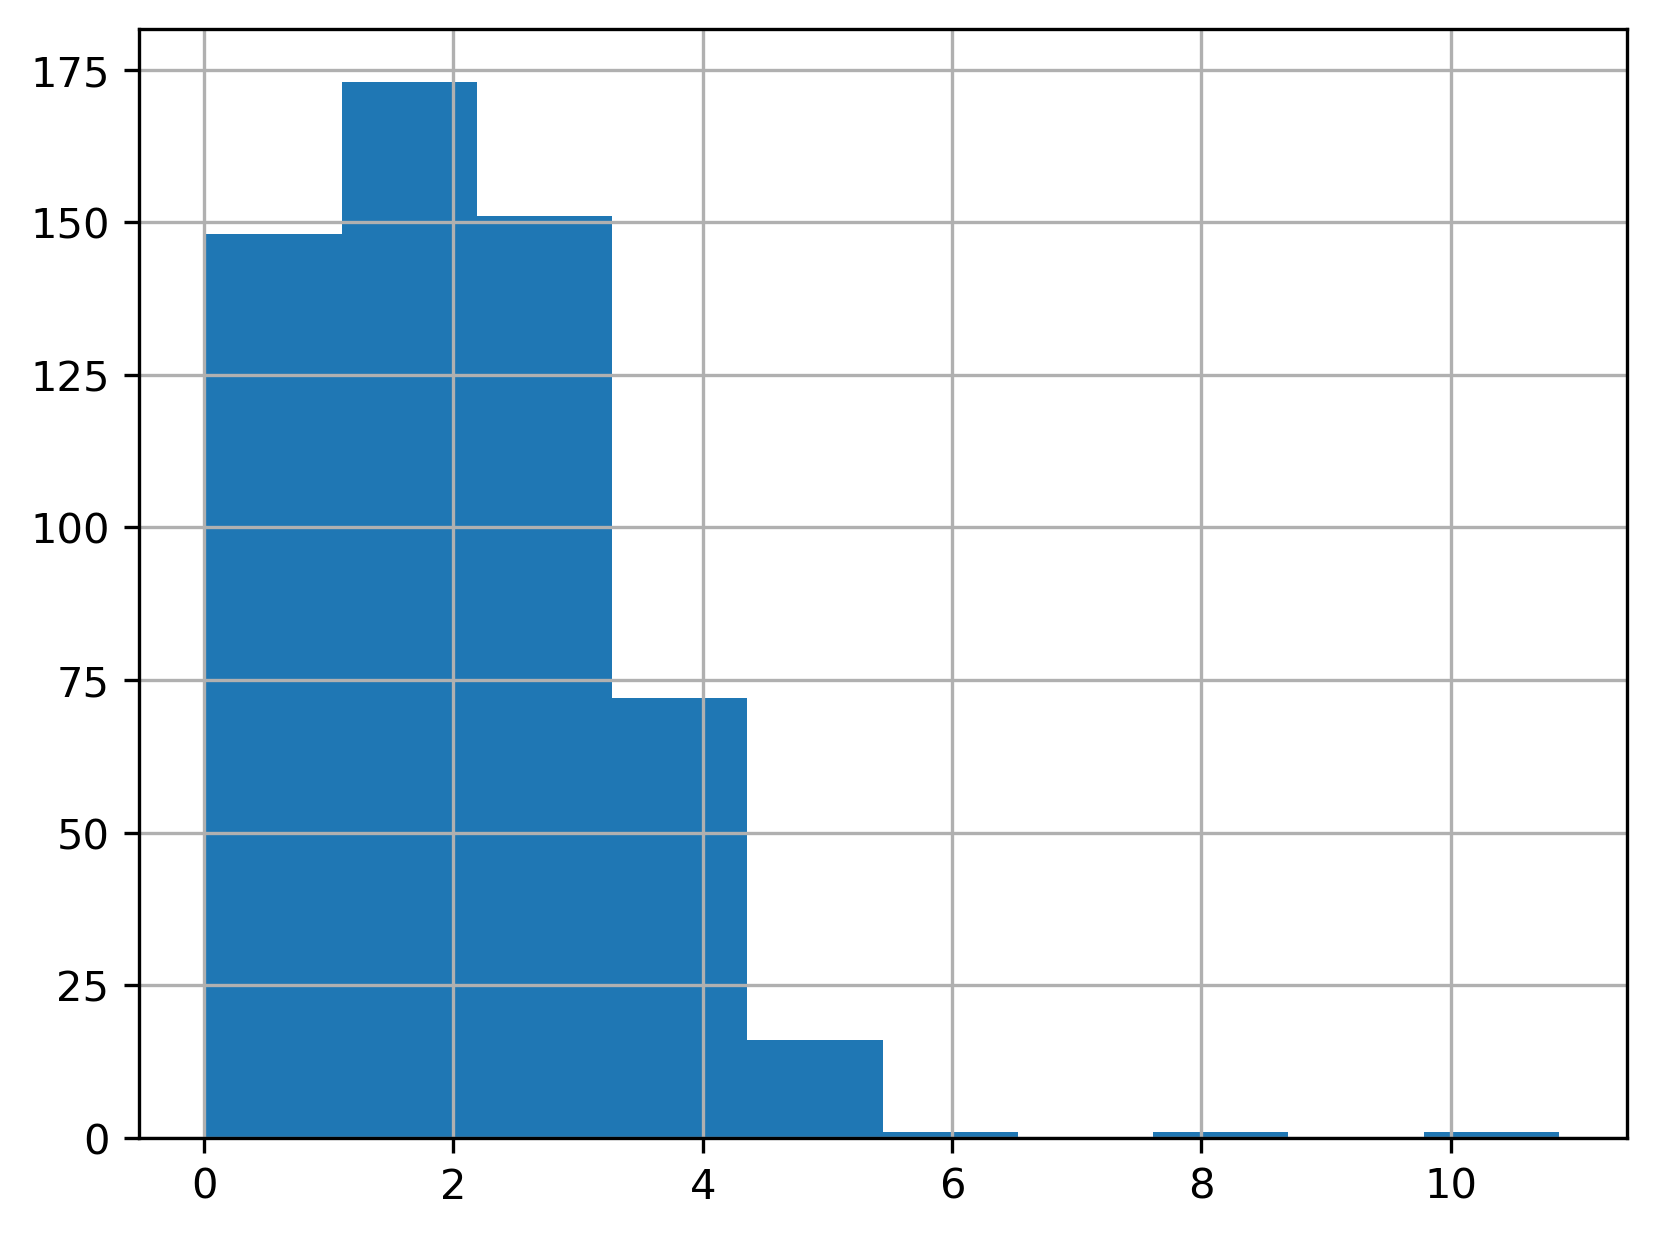

In [228]:
data['slope_200'].hist()

In [128]:
data['landform'].unique()

array([0, 1])

In [129]:
data.groupby(['Landform', 'landform']).count()['system:index']

Landform             landform
Fan terraces, hills  0           155
                     1            14
Flood plains         0            89
                     1           164
Stream terraces      0            39
                     1           102
Name: system:index, dtype: int64

In [130]:
data.groupby(["ParentMaterial", "Condition"]).count()['system:index']

ParentMaterial                                                                     Condition
Alluvium derived from granite and/or alluvium derived from schist                  Degraded      45
                                                                                   Intact        21
Alluvium derived from schist and/or alluvium derived from granite, Mixed alluvium  Degraded      37
                                                                                   Intact        27
Mixed alluvium                                                                     Degraded      98
                                                                                   Intact       142
Moderately fine textured alluvium, Moderately coarse textured alluvium             Degraded      95
                                                                                   Intact        98
Name: system:index, dtype: int64

In [168]:
data['effective'] = np.nan
data.loc[data['effect_percent'] > 6, 'effective'] =  True
data.loc[data['effect_percent'] < 5, 'effective']= False




In [169]:
data['Effective'] = np.nan
data.loc[data['effect_percent'] > 6, 'Effective'] =  'Effective'
data.loc[data['effect_percent'] < 5, 'Effective']=  'Ineffective'




In [187]:
data['High_Clay'] = data['surfclaybg'] > 24

data['Landform_stability'] = data['Landform'].replace({
    'Fan terraces, hills': 'Stable',
    'Stream terraces': 'Stable',
    'Flood plains': 'Unstable'
})

In [188]:
data['Intact'] = data['Condition'] == 'Intact'

<Axes: xlabel='Slope_Class', ylabel='Count'>

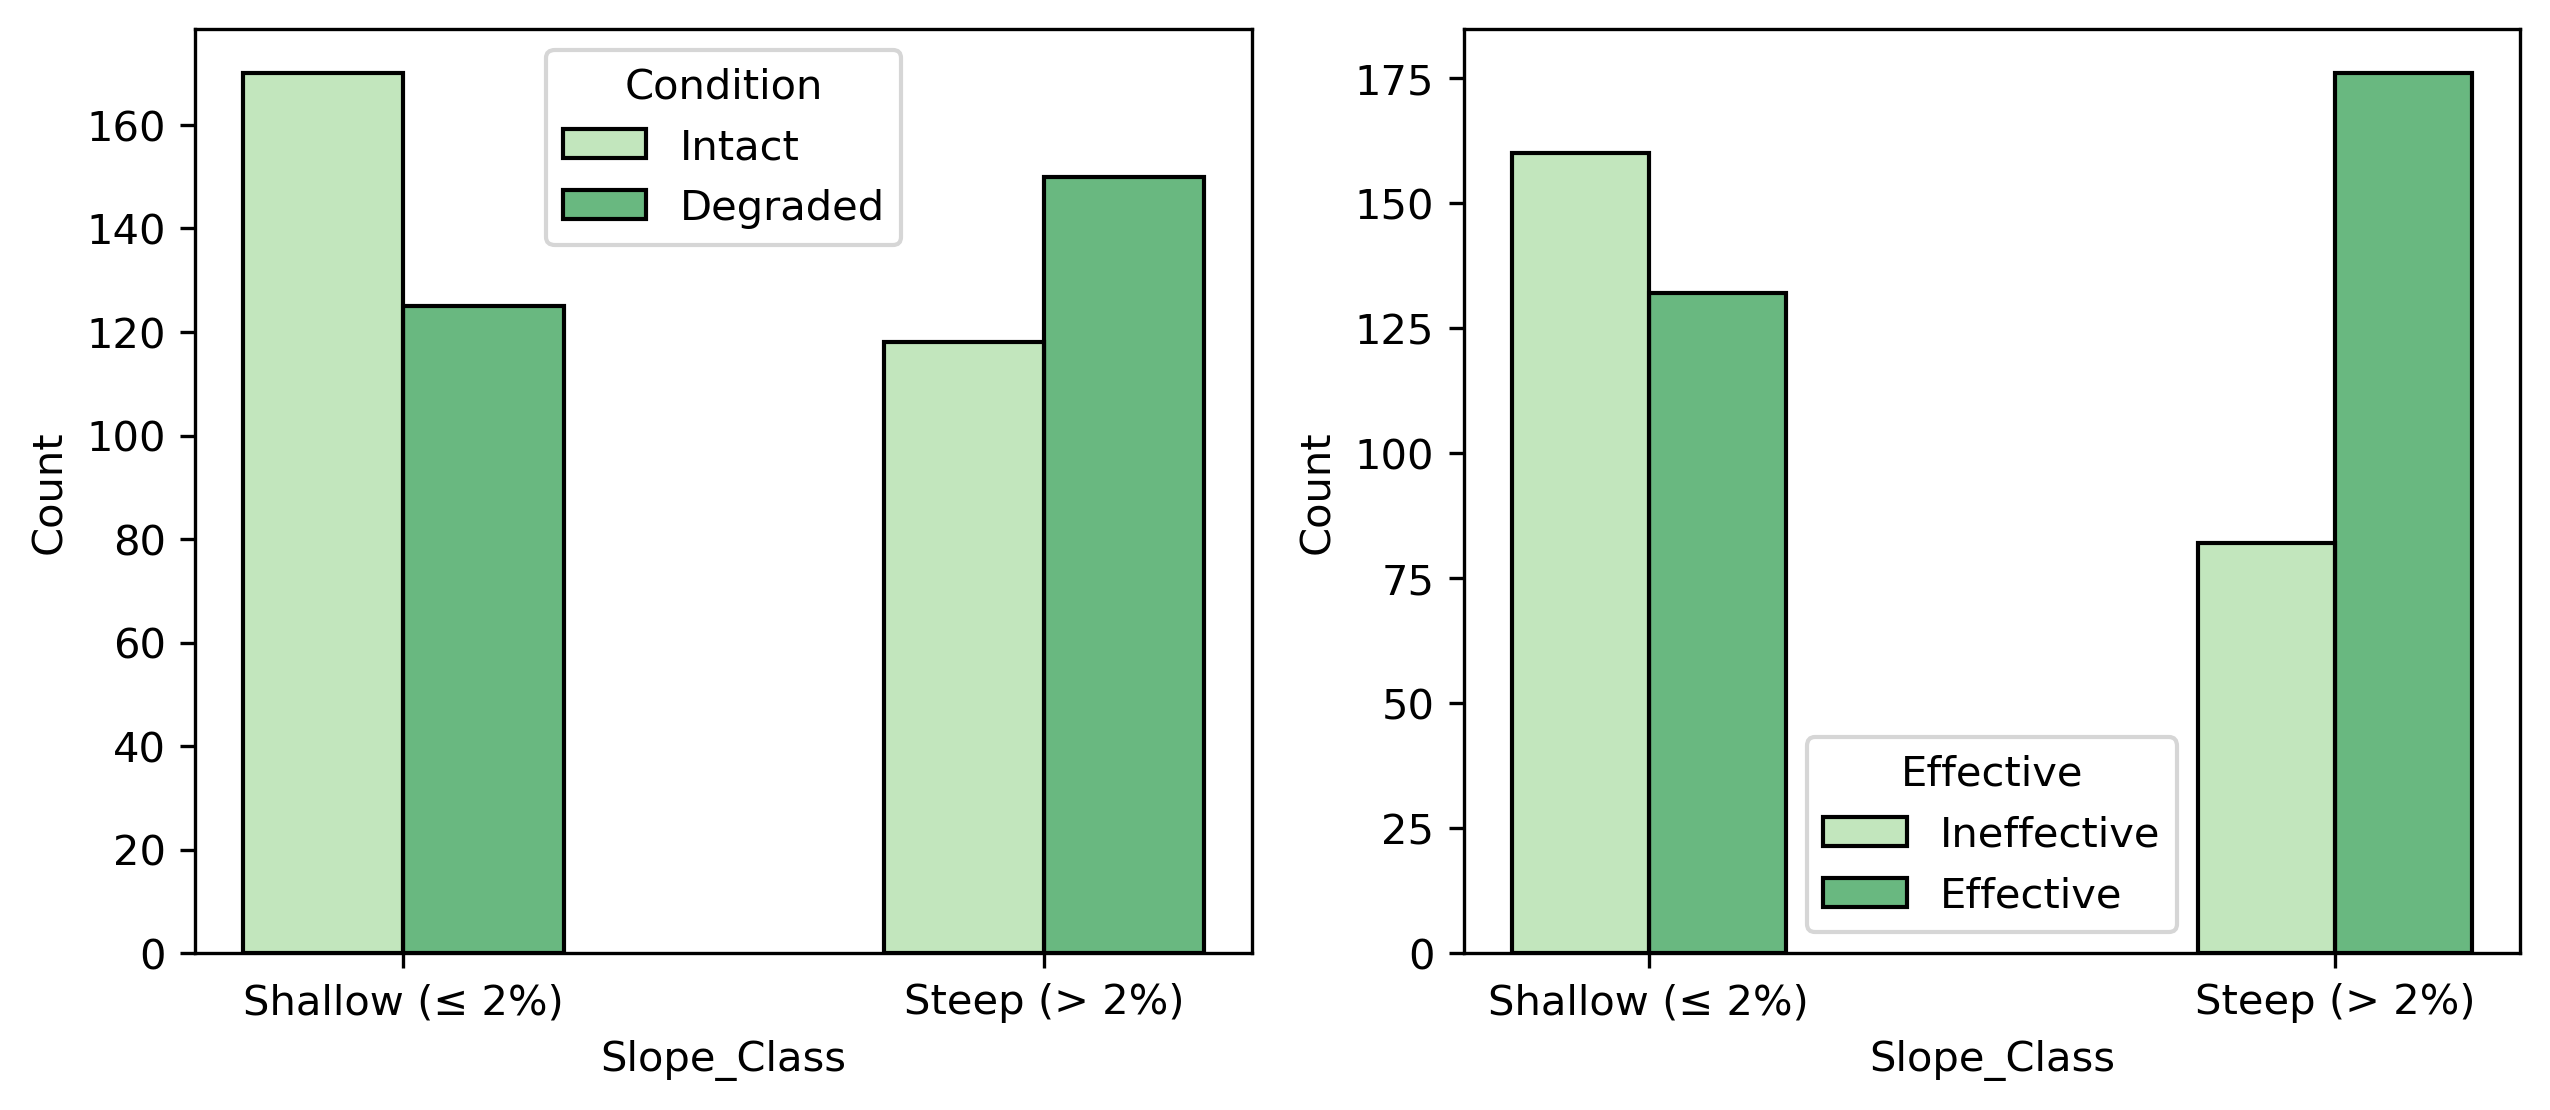

In [194]:
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings('ignore')

import seaborn as sns


fig, axes = plt.subplots(1, 2, figsize = (10,4))
sns.histplot (data =  data.sort_values("landform",ascending =  True), ax = axes[0],
              hue = 'Condition' , x ='Slope_Class', palette = 'Greens',
              shrink = 0.5, multiple ='dodge')

sns.histplot (data =  data.sort_values("landform",ascending =  True),
              hue = 'Effective' , x ='Slope_Class', ax= axes[1],
              palette = 'Greens', shrink = 0.4, multiple ='dodge')


<Axes: xlabel='Landform', ylabel='Count'>

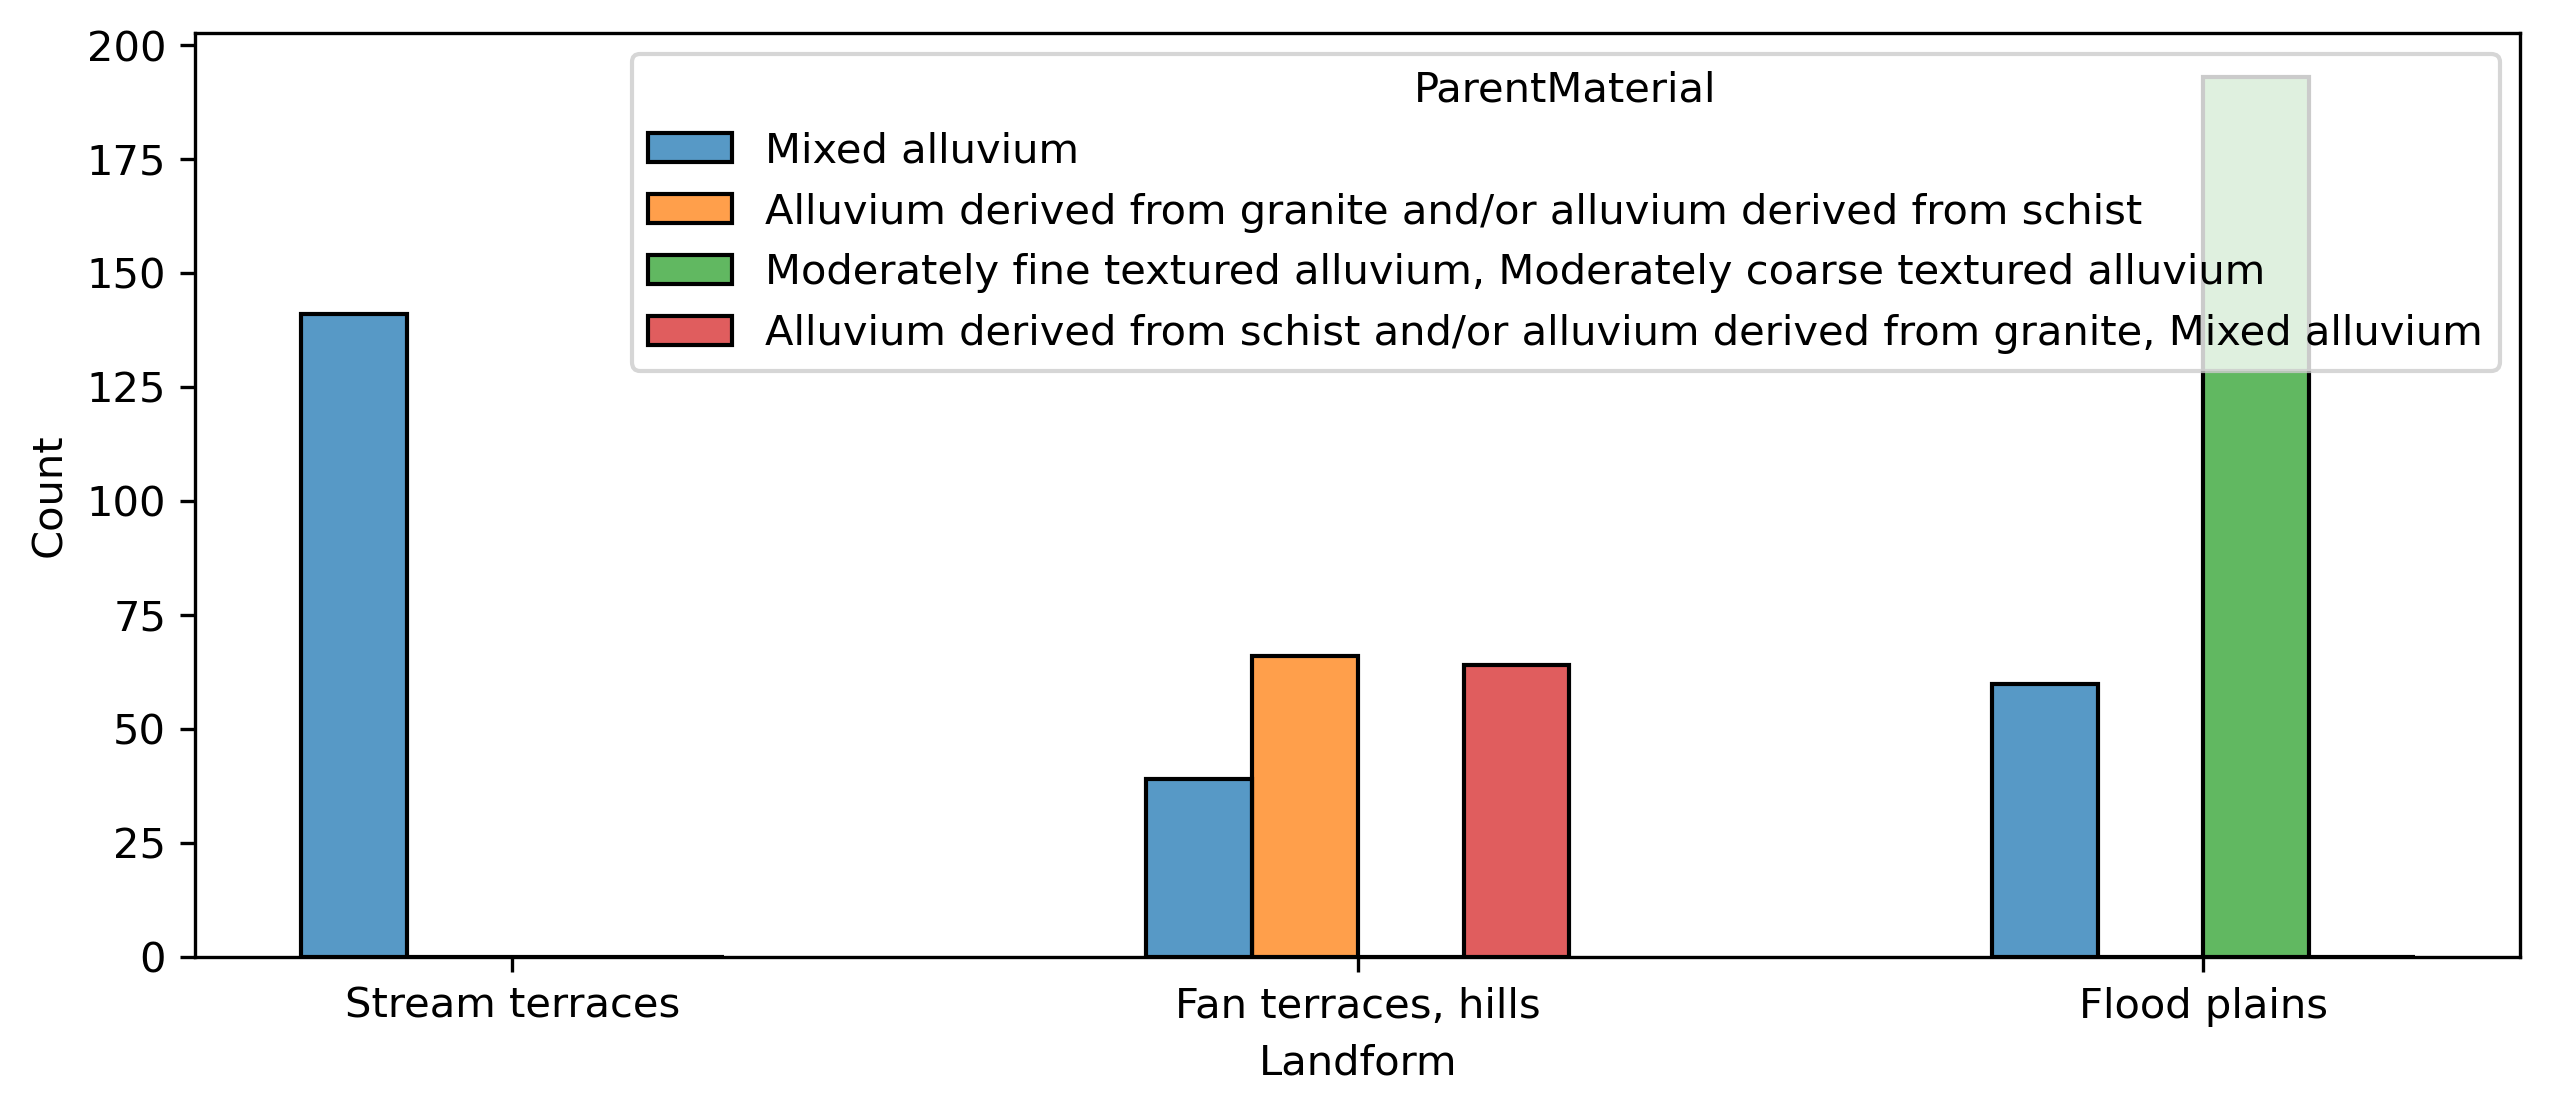

In [197]:

fig, axes = plt.subplots(1, figsize = (10,4))
sns.histplot(data = data, x = 'Landform' , hue ='ParentMaterial', 
             shrink = 0.5, multiple ='dodge')

# sns.histplot(data = balanced_data.sort_values('Landform'), x = 'Landform' , hue ='effective',ax= axes,
#              shrink = 0.5, multiple ='dodge')


In [198]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import fisher_exact, chi2_contingency

def analyze_threshold_proportions(data, threshold_var, threshold_name, bins, largeName = 'Large', 
                                     smallName = 'Small'):
    results = []

    for threshold in bins:
        high = data.query("{0} > @threshold".format(threshold_var))
        low = data.query("{0} <= @threshold".format(threshold_var))

        # Degraded counts
        high_degraded = (high['Condition'] == 'Degraded').sum()
        high_intact = (high['Condition'] == 'Intact').sum()
        low_degraded = (low['Condition'] == 'Degraded').sum()
        low_intact = (low['Condition'] == 'Intact').sum()

        total_high = high_degraded + high_intact
        total_low = low_degraded + low_intact
        prop_degraded_high = high_degraded / total_high if total_high > 0 else np.nan
        prop_degraded_low = low_degraded / total_low if total_low > 0 else np.nan

        # Effective counts
        high_effective = (high['effective'] == 1).sum()
        high_ineffective = (high['effective'] == 0).sum()
        low_effective = (low['effective'] == 1).sum()
        low_ineffective = (low['effective'] == 0).sum()

        total_high_eff = high_effective + high_ineffective
        total_low_eff = low_effective + low_ineffective
        prop_effective_high = high_effective / total_high_eff if total_high_eff > 0 else np.nan
        prop_effective_low = low_effective / total_low_eff if total_low_eff > 0 else np.nan

        # Contingency tables
        table_degraded = [[low_degraded, low_intact],
                           [high_degraded, high_intact]]
        table_effective = [[low_effective, low_ineffective],
                            [high_effective, high_ineffective]]

        # Significance tests - degraded
        try:
            fisher_p = fisher_exact(table_degraded)[1]
        except:
            fisher_p = np.nan
        try:
            chi2_p = chi2_contingency(table_degraded)[1]
        except:
            chi2_p = np.nan

        # Significance tests - effective
        try:
            fisher_p_eff = fisher_exact(table_effective)[1]
        except:
            fisher_p_eff = np.nan
        try:
            chi2_p_eff = chi2_contingency(table_effective)[1]
        except:
            chi2_p_eff = np.nan

        results.append({
            'threshold': threshold,
            'high_proportion_degraded': prop_degraded_high,
            'low_proportion_degraded': prop_degraded_low,
            'high_proportion_effective': prop_effective_high,
            'low_proportion_effective': prop_effective_low,
            'fisher_p_degraded': fisher_p,
            'chi2_p_degraded': chi2_p,
            'significant_degraded': fisher_p < 0.05 if not np.isnan(fisher_p) else False,
            'fisher_p_effective': fisher_p_eff,
            'chi2_p_effective': chi2_p_eff,
            'significant_effective': fisher_p_eff < 0.05 if not np.isnan(fisher_p_eff) else False,
            # Include counts
            'high_degraded': high_degraded,
            'high_intact': high_intact,
            'low_degraded': low_degraded,
            'low_intact': low_intact,
            'high_effective': high_effective,
            'high_ineffective': high_ineffective,
            'low_effective': low_effective,
            'low_ineffective': low_ineffective,
            # Total counts for filtering
            'total_high': total_high,
            'total_low': total_low
        })

    results_df = pd.DataFrame(results)

    # Filter: only show thresholds with at least 15 samples in either low or high
    filtered_df = results_df.query("high_degraded >= 10 and  low_degraded >= 10")

    # Plotting
    fig, axes = plt.subplots(2, 1, figsize=(8, 7), sharex=True, sharey = True)
    high_color = "C1"
    low_color = "C0"

    sig_degraded = filtered_df['significant_degraded']
    sig_effective = filtered_df['significant_effective']

    # Panel: Degraded Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5,
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='low_proportion_degraded',
        ax=axes[0], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_degraded], x='threshold', y='high_proportion_degraded',
        ax=axes[0], color=high_color, marker='s',
    )
    axes[0].set_title("Degraded Fraction")
    axes[0].set_ylabel("Degraded Fraction")
    axes[0].legend()

    filtered_df = results_df.query("high_effective >= 10 and  low_effective >= 10")    
    # Panel 2: Effective Fraction
    sns.scatterplot(
        data=filtered_df, x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='o', label="{1} {0}".format(threshold_name, smallName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='low_proportion_effective',
        ax=axes[1], color=low_color, marker='s',
    )
    sns.scatterplot(
        data=filtered_df, x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='o', label="{1} {0}".format(threshold_name, largeName), alpha=0.5
    )
    sns.scatterplot(
        data=filtered_df[sig_effective], x='threshold', y='high_proportion_effective',
        ax=axes[1], color=high_color, marker='s',
    )
    axes[1].set_title(r"`Effective' fraction ($\Delta S > 10$)")
    axes[1].set_xlabel("{0} threshold".format(threshold_name))
    axes[1].set_ylabel("Effective Fraction")
    axes[1].legend()

    plt.tight_layout()

    return results_df, fig


1. What is predictive of berm state / intactness?
  Longer berms more likely to be degraded. (a) more failure points and (b) where berm constructud.
2. What is predictive of berm impact on surrounding vegetation, referred to here as 'effectiveness'
3. What is the correspondence between these things.

### Potential SI Figures

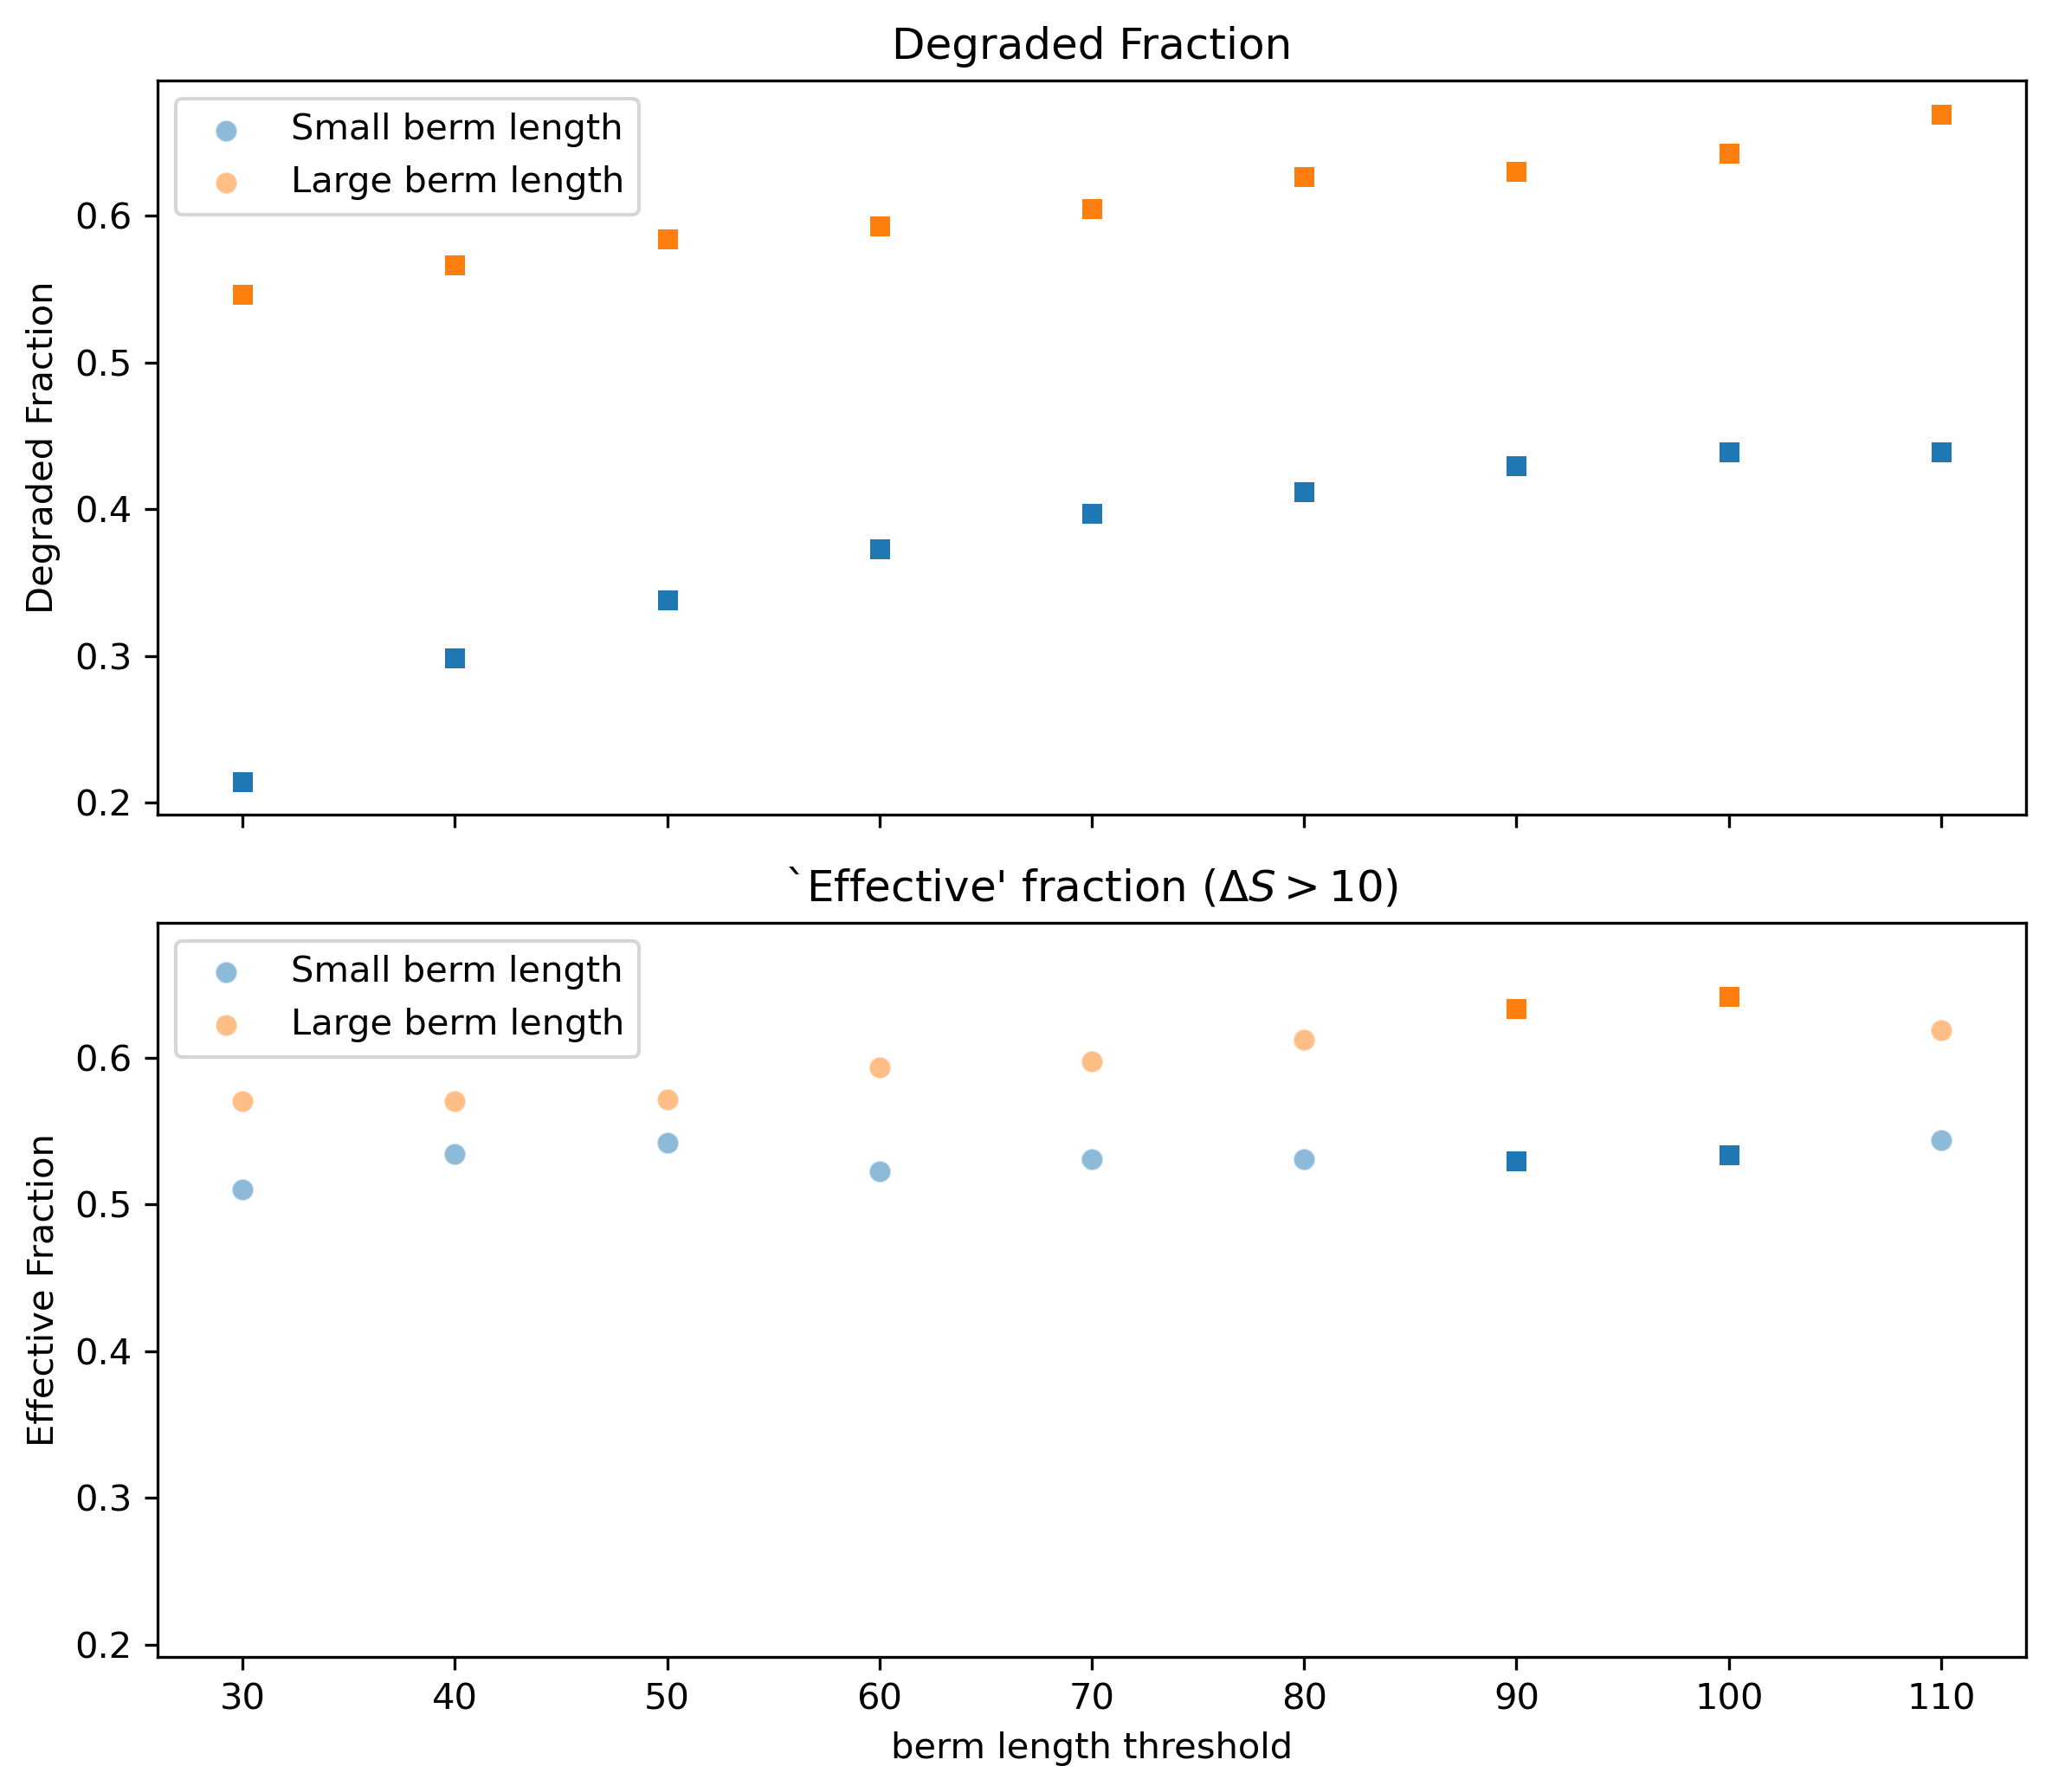

In [199]:
# Example usage:
results_df, fig = analyze_threshold_proportions(data, 'Shape_Leng', 'berm length', np.arange(0, 120, 10))
fig.savefig('single_variable_plots/Shape_Leng.png')

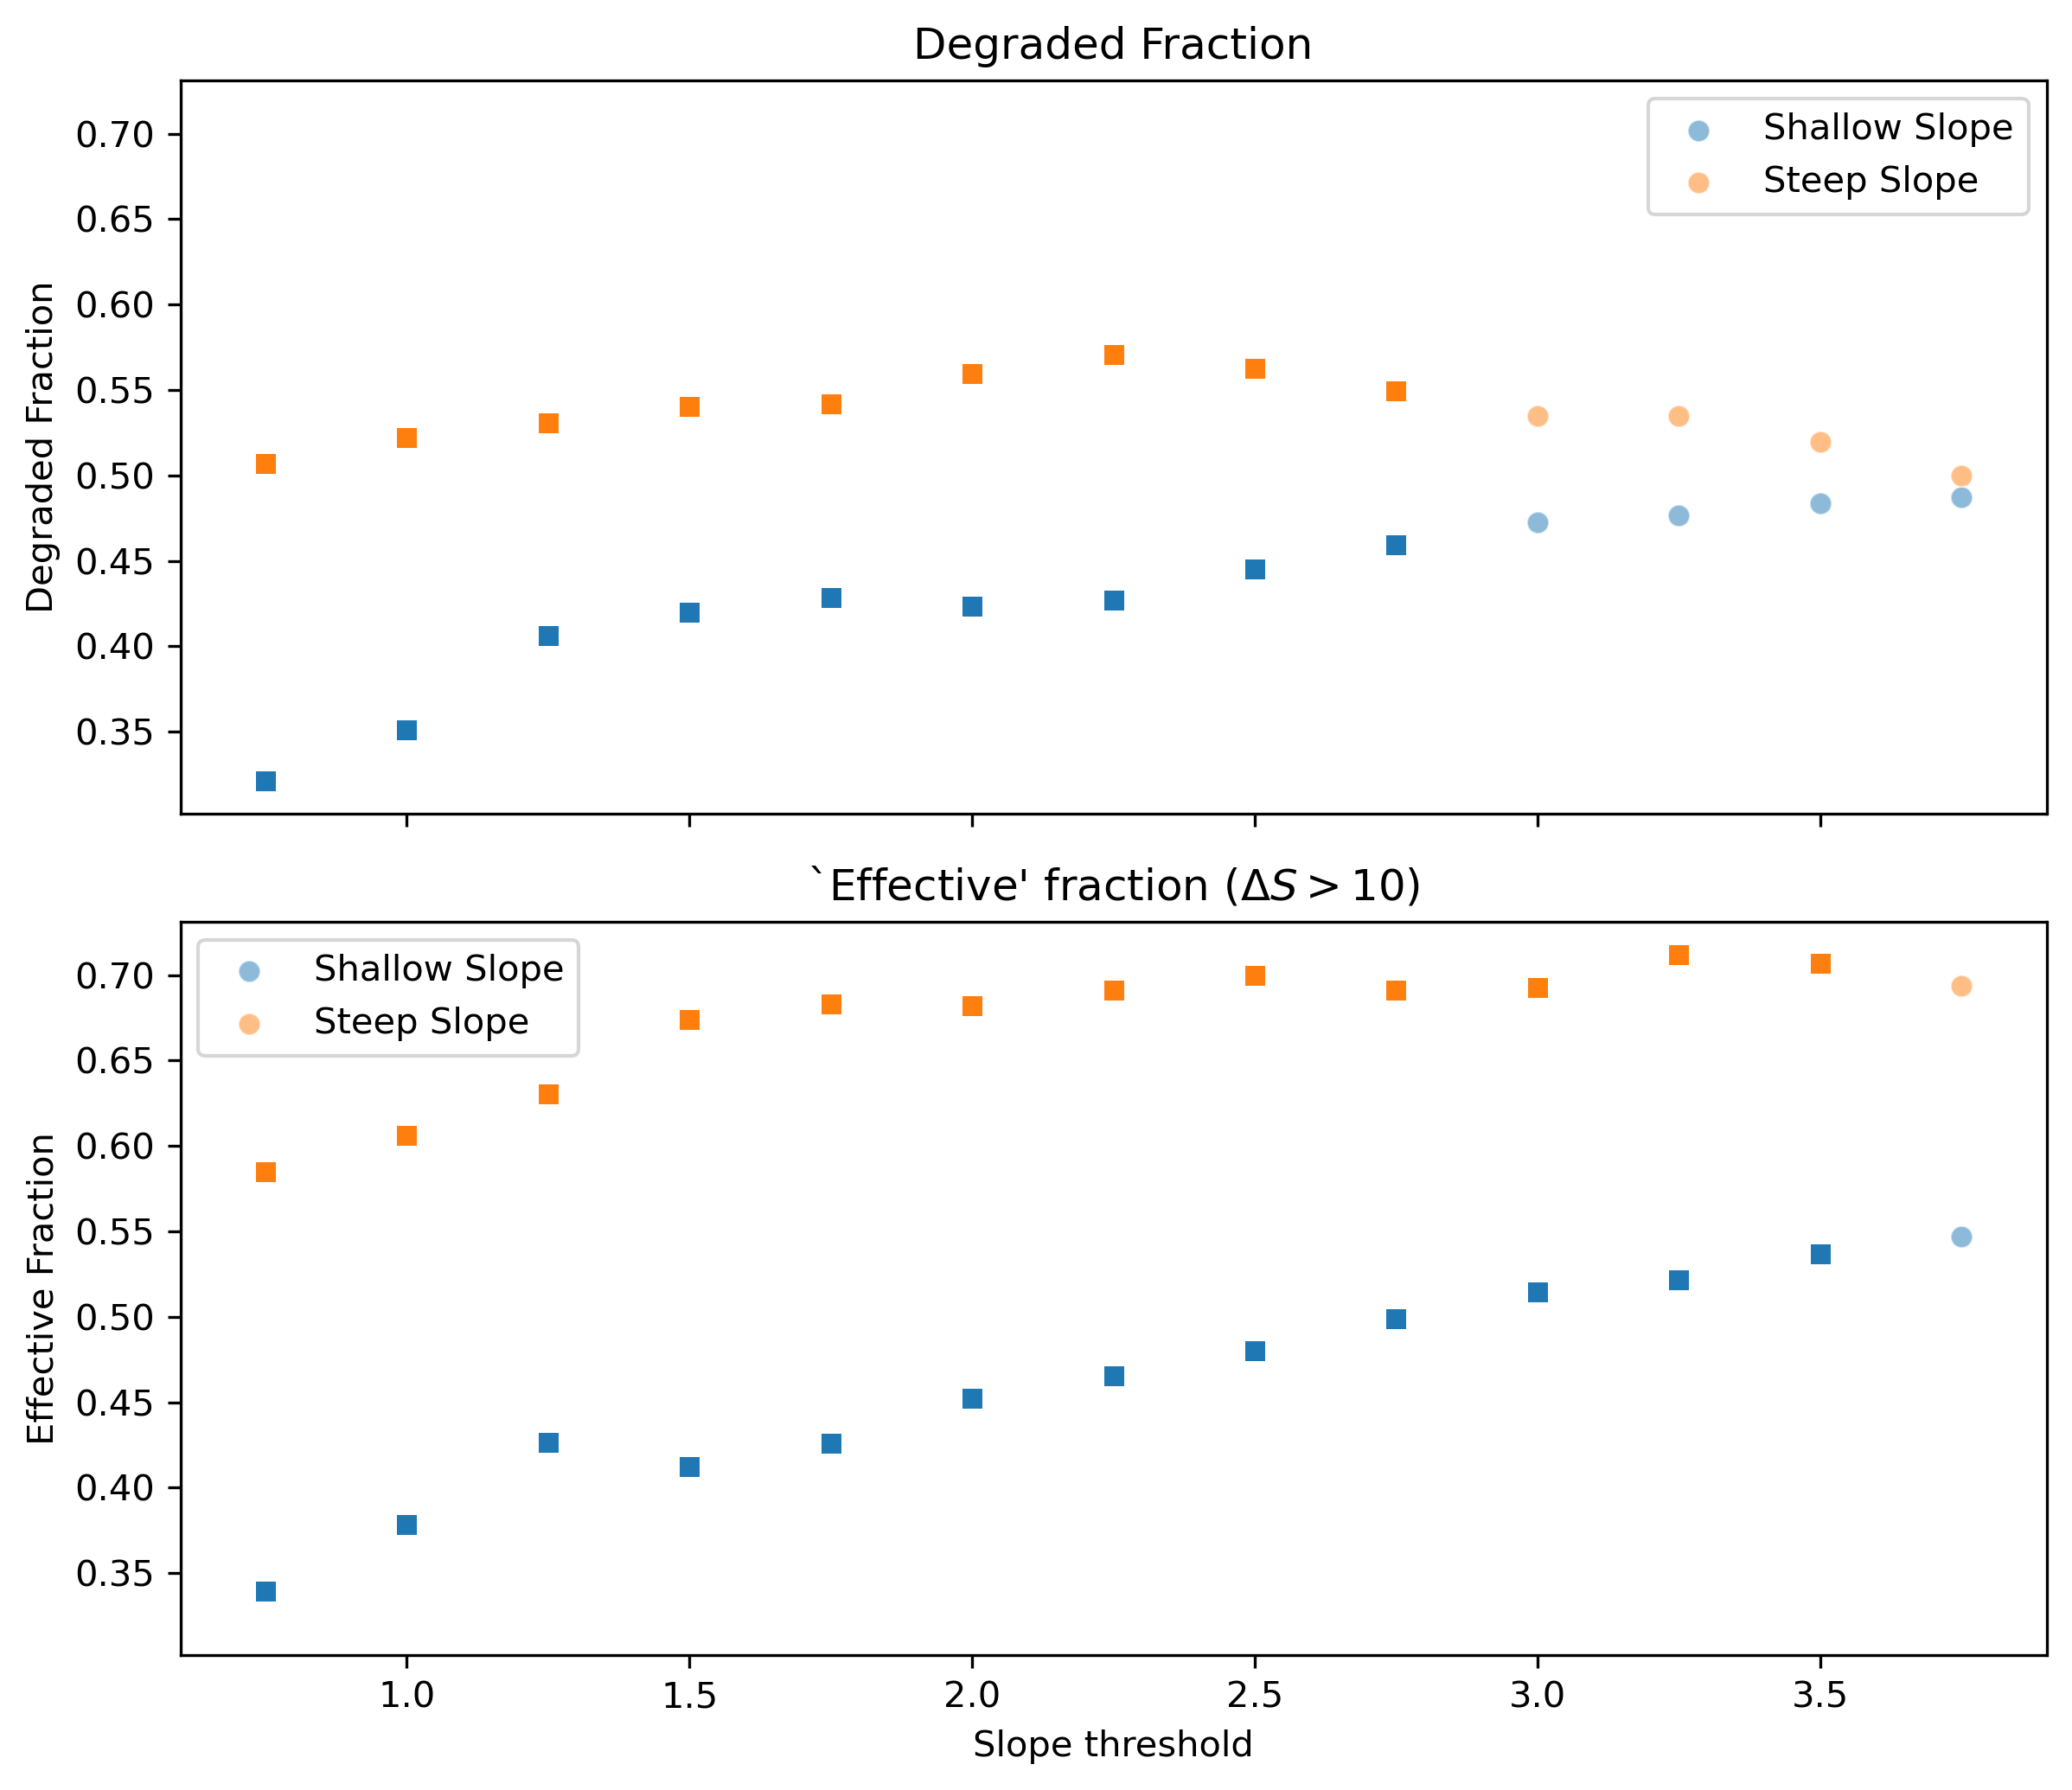

In [200]:
results_df, fig = analyze_threshold_proportions(data, 'slope_100', 'Slope', np.arange(0, 4, 0.25), largeName = 'Steep', smallName = 'Shallow' )
fig.savefig('single_variable_plots/Slope.png')

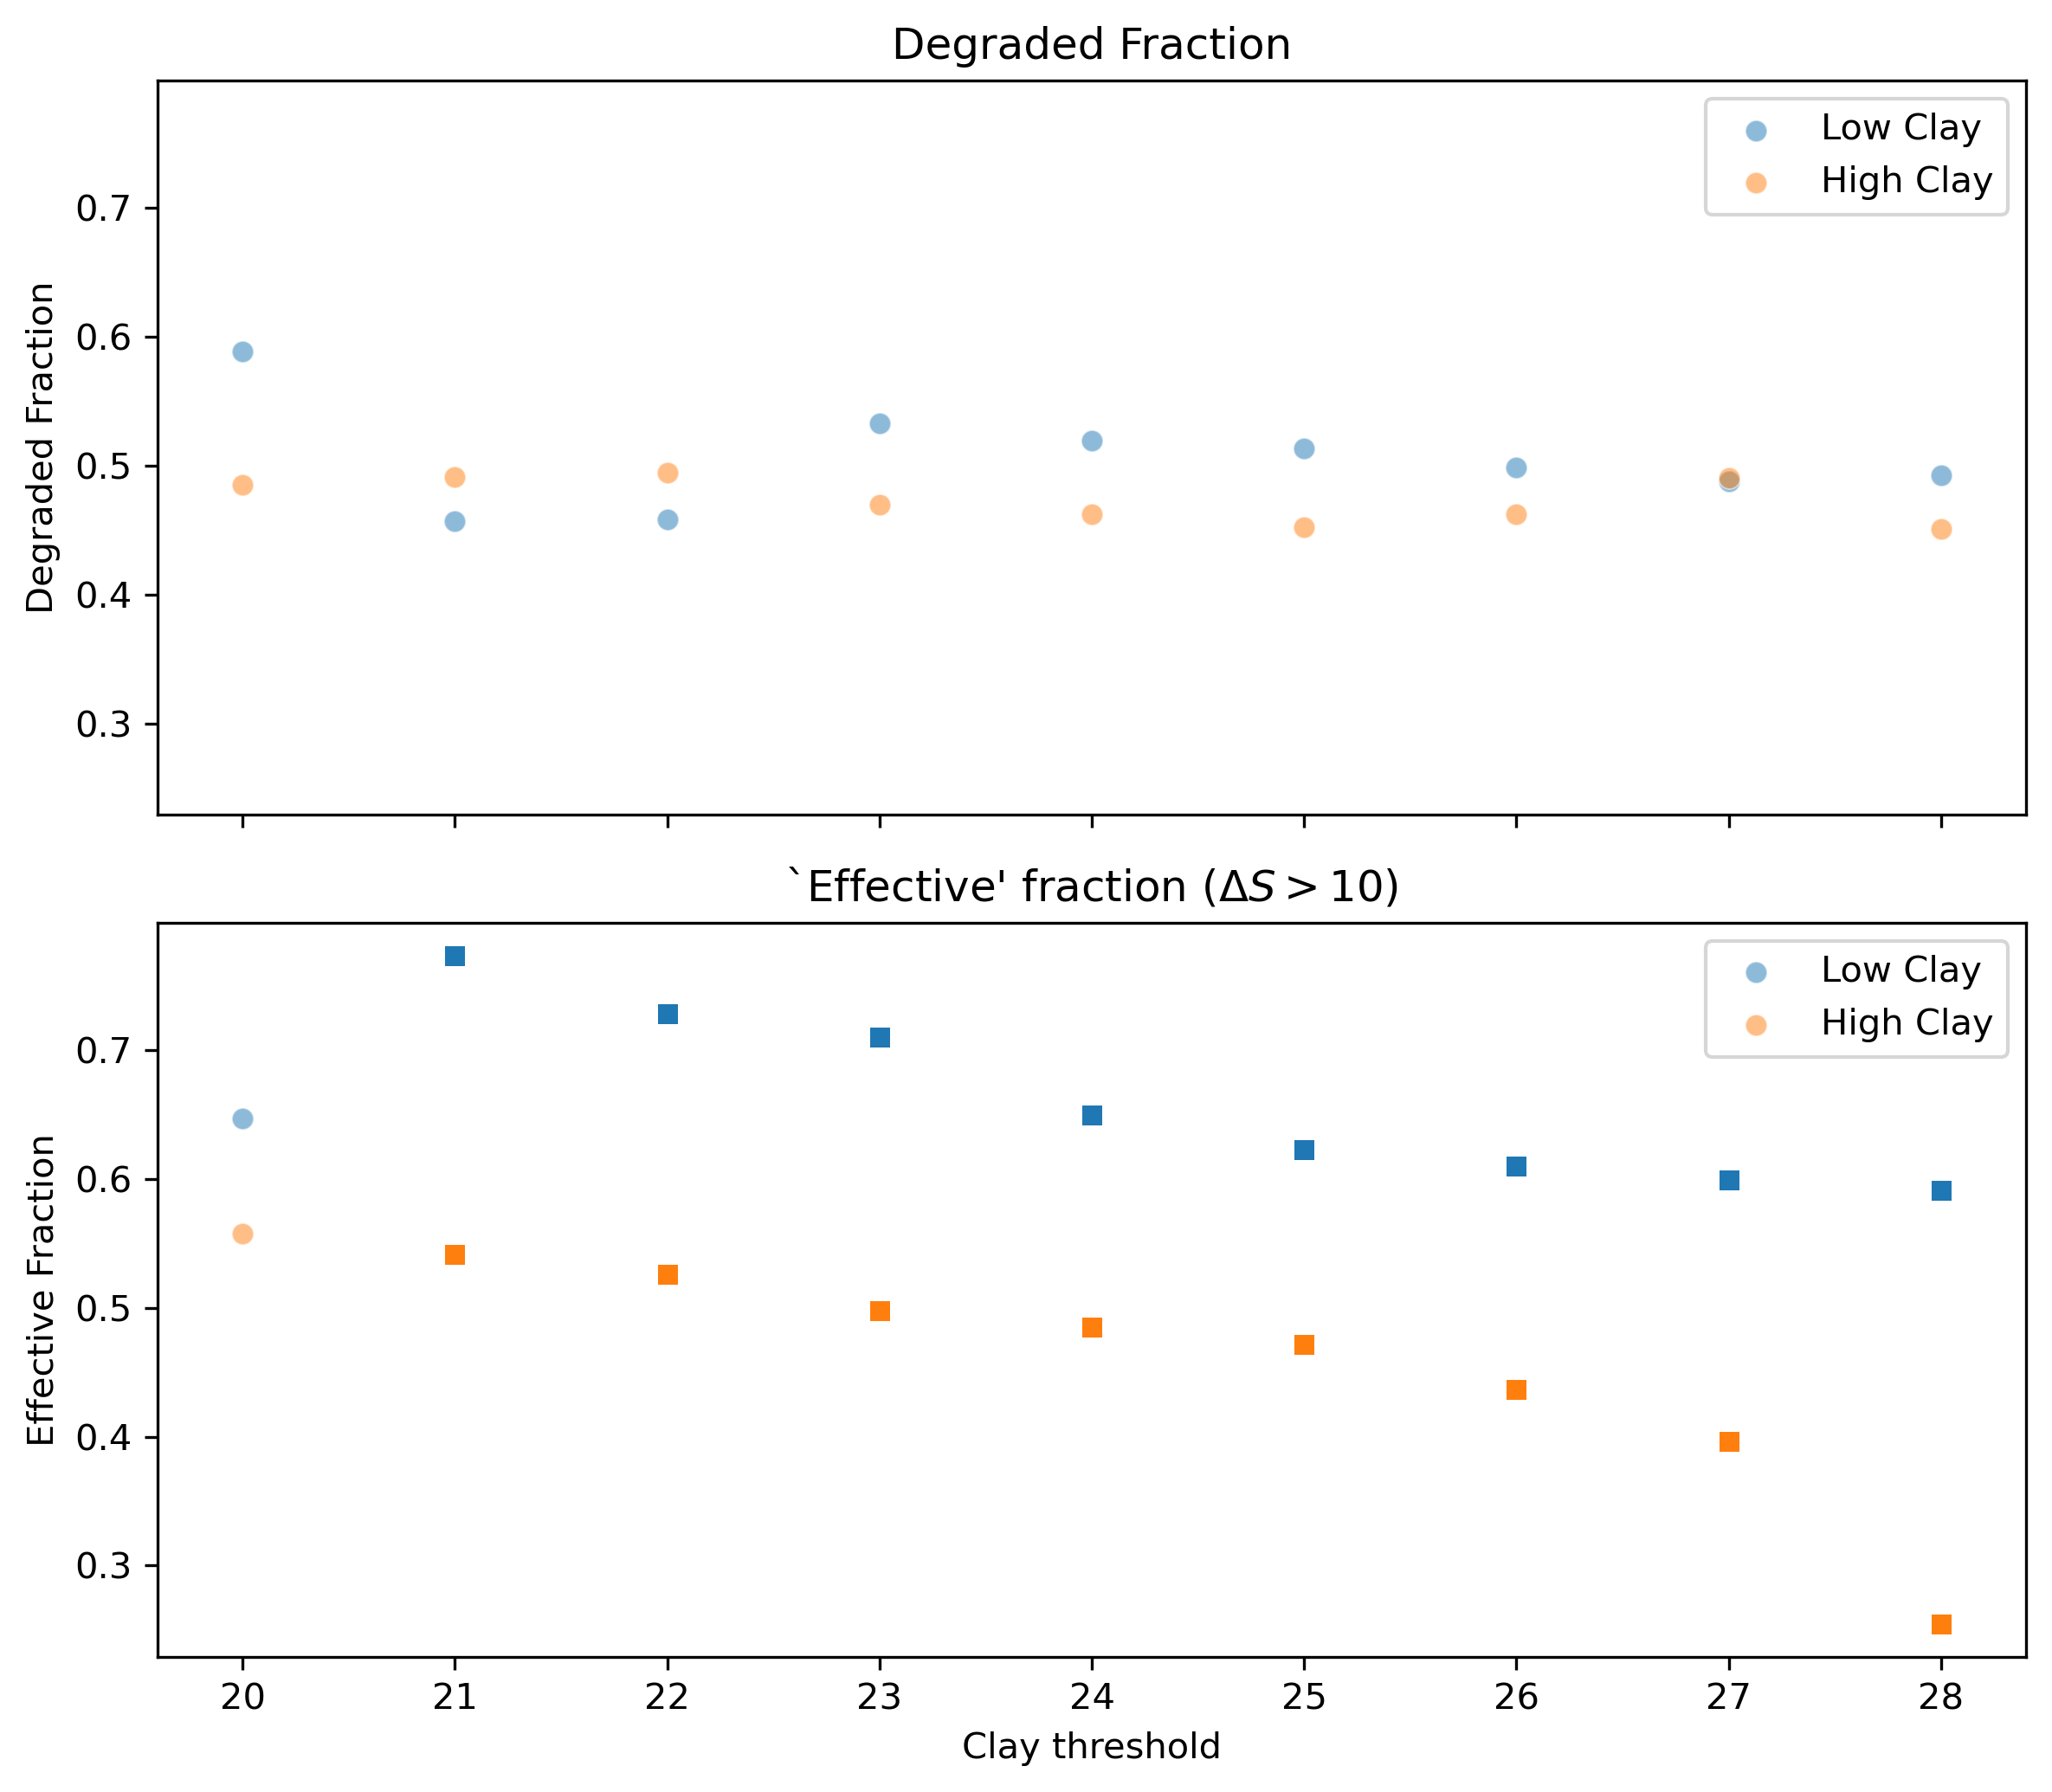

In [201]:
results_df, fig = analyze_threshold_proportions(data, 'surfclaybg', 'Clay', np.arange(18, 30, 1), 
                                                largeName = 'High', smallName = 'Low' )
fig.savefig('single_variable_plots/Clay.png')

In [202]:
data.columns

Index(['system:index', 'AREASYMBOL', 'Fail_Type', 'MUKEY', 'MUSYM', 'Note',
       'Notes', 'Shape_Leng', 'Structure_', 'Type', 'aspectD_60', 'aspectU_60',
       'berm_angle', 'berm_elev', 'compare', 'convD_60', 'convU_60', 'id',
       'landform', 'latitude', 'longitude', 'other_dist', 'other_elev',
       'road_dist', 'saviD_60', 'saviU_60', 'savi_background', 'slopeD_100',
       'slopeD_200', 'slopeD_60', 'slopeU_100', 'slopeU_200', 'slopeU_60',
       'slope_100', 'slope_200', 'surfclayD_60', 'surfclayU_60',
       'surfclay_background', 'surfclaybg', 'surfsandD_60', 'surfsandU_60',
       'surfsand_background', 'surfsandbg', 'surfsocD_60', 'surfsocU_60',
       'surfsoc_background', 'surfsocbg', 'zD_60', 'zU_60', '.geo',
       'MapUnitName', 'SlopeClass', 'Landform', 'ParentMaterial',
       'TypicalProfile', 'Condition', 'effect', 'effect_percent',
       'landform_stability', 'Berm_Length_Class', 'Slope_Class',
       'Soil_Development', 'effective', 'High_Clay', 'Landform_st

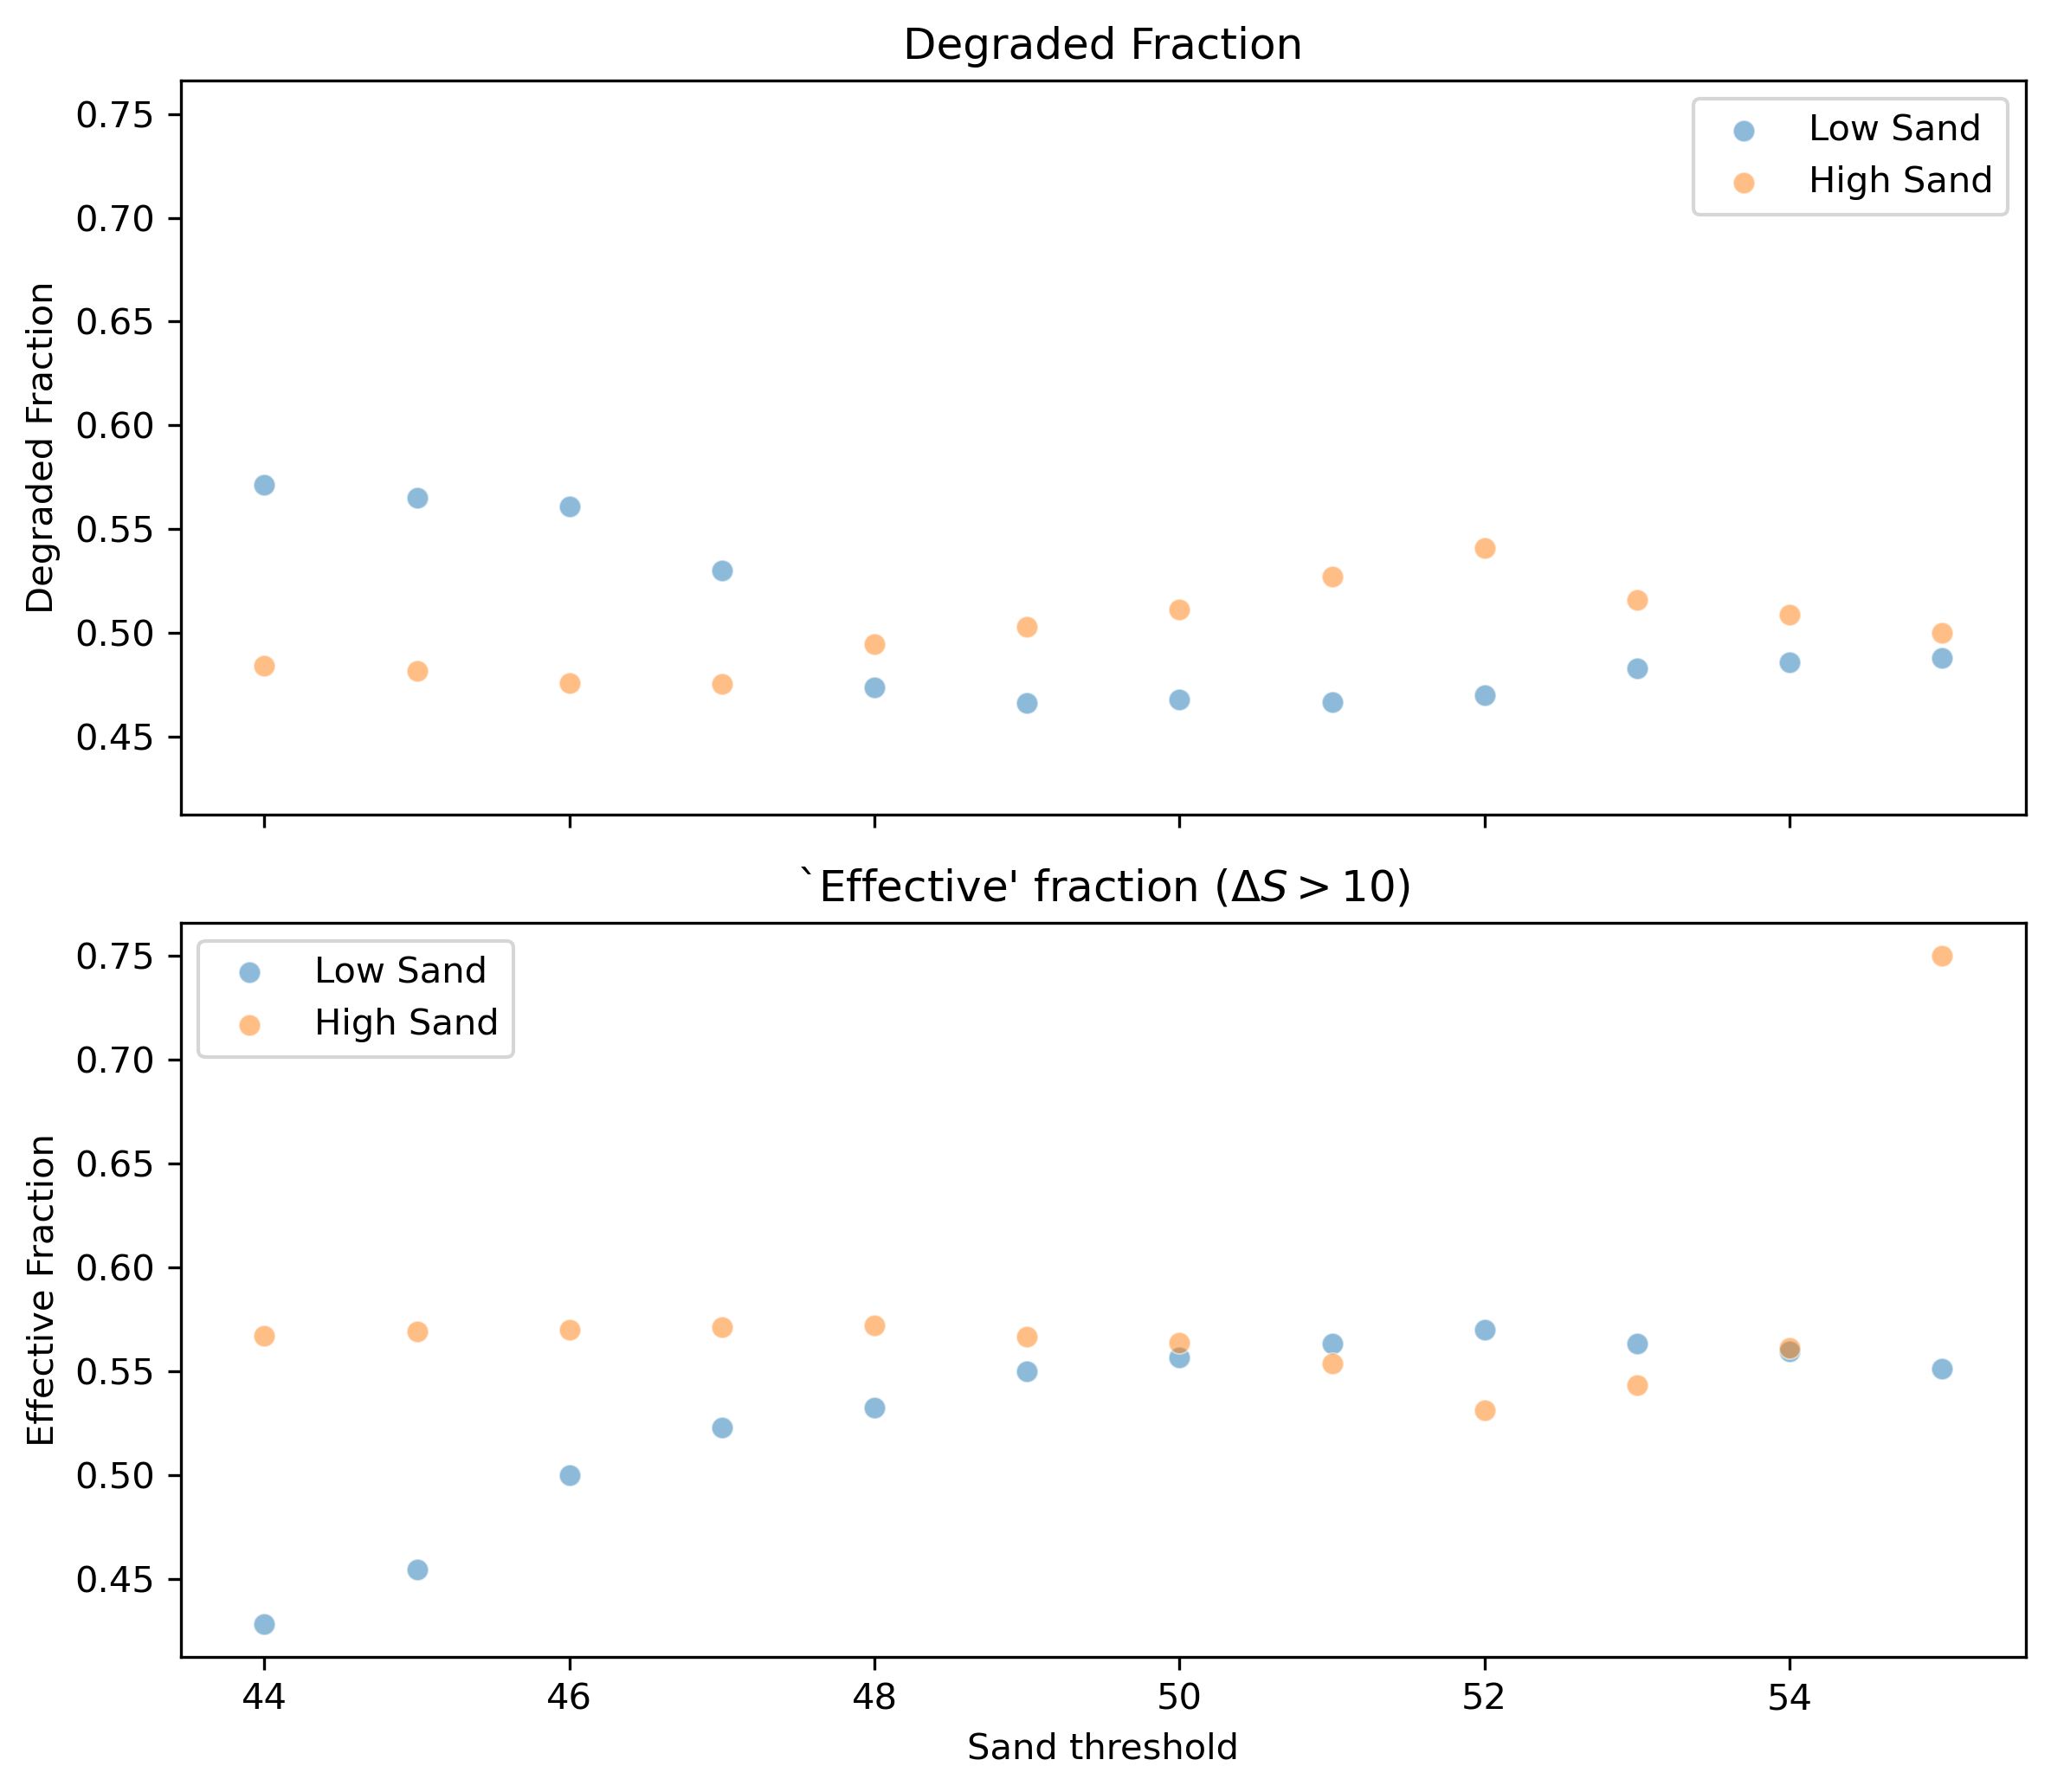

In [203]:
results_df, fig = analyze_threshold_proportions(data, 'surfsandbg', 'Sand', np.arange(40, 60, 1), 
                                                largeName = 'High', smallName = 'Low' )
fig.savefig('single_variable_plots/Sand.png')

## General case

In [204]:
import pandas as pd



def balanced_sample(df, group_cols, partition_col):
    # Drop rows with missing values in relevant columns
    cols_required = group_cols + [partition_col]
    df = df.dropna(subset=cols_required)

    grouped = df.groupby(group_cols + [partition_col])
    ct = grouped.size().unstack(partition_col, fill_value=0)

    samples = []
    for idx, row in ct.iterrows():
        partition_values = row.index.tolist()
        min_n = row.min()

        # Skip unbalanced groups
        if row.nunique() == 1 or min_n == 0:
            print(f"Skipping unbalanced group: {idx} | Counts: {row.to_dict()}")
            continue

        group_filter = dict(zip(group_cols, idx if isinstance(idx, tuple) else (idx,)))
        for part_value in partition_values:
            subset = df.copy()
            for col, val in group_filter.items():
                subset = subset[subset[col] == val]
            subset = subset[subset[partition_col] == part_value]
            samples.append(subset.sample(n=min_n, random_state=42))

    return pd.concat(samples).reset_index(drop=True)



In [205]:
partition_col = 'Landform'

# Open file for writing
with open('landform_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\n Berm length / landform correspondence")
    
    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Berm_Length_Class']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    
    f.write("\n Slope  / landform correspondence")
    
    summary_counts = data.groupby([partition_col, 'Slope_Class']).size().unstack(fill_value=0)
    f.write("\nBerm Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")    
    
 

In [206]:
len(data)

563

In [207]:
partition_col = 'Soil_Development'

# Open file for writing
with open('soil_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Slope_Class']   
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Slope_Class', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

In [208]:
# Choose grouping and partition variables
partition_col = 'Slope_Class'

# Open file for writing
with open('slope_summary.txt', 'w') as f:
    f.write("\nUnbalanced effective:\n")
    
    summary_counts = data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    f.write("\nBerm effective Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    f.write("\nUnbalanced intact:\n")
    summary_counts = data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm intact Counts :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    

    group_cols = ['Landform']    
    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")
    
    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")

    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 
    group_cols = ['Landform', 'Berm_Length_Class']    

    f.write("-------\n")
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
    

    # Apply balancing function
    balanced_data = balanced_sample(data, group_cols=group_cols, partition_col=partition_col)

    # Split and summarize
    partitions = balanced_data[partition_col].unique()
    f.write("\nSample sizes per partition:\n")
    for part in partitions:
        count = balanced_data[balanced_data[partition_col] == part].shape[0]
        f.write(f"{part}: {count}\n")

    f.write("\nSample breakdown by group:\n")
    group_counts = balanced_data.groupby([partition_col] + group_cols).size()
    f.write(group_counts.to_string())
    f.write("\n")

    
    summary_counts = balanced_data.groupby([partition_col, 'effective']).size().unstack(fill_value=0)
    
    f.write("\n")
    f.write("\nBerm counts  :\n")
    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
    f.write("\nBalanced: " + ', '.join(group_cols) + "\n")
  
    summary_counts = balanced_data.groupby([partition_col, 'Intact']).size().unstack(fill_value=0)
    f.write("\nBerm counts  :\n")
    f.write(summary_counts.to_string())
    f.write("\n")

    summary_proportions = summary_counts.div(summary_counts.sum(axis=1), axis=0).round(2)
    f.write("\nProportion  :\n")
    f.write(summary_proportions.to_string())
    f.write("\n")
    
 

In [209]:
data.query("Type == 'Berm'").shape

(506, 67)

In [210]:
data['Type'].unique()

array(['Berm', 'Spur', 'Check dam', 'Concrete Structure',
       'Rock Gabion Structure'], dtype=object)

(array([123., 145., 115.,  63.,  46.,  22.,  17.,   7.,   5.,   6.,   5.,
          1.,   2.,   1.,   1.,   2.,   0.,   1.,   0.,   1.]),
 array([  9.04243518,  34.64875541,  60.25507565,  85.86139589,
        111.46771613, 137.07403637, 162.6803566 , 188.28667684,
        213.89299708, 239.49931732, 265.10563755, 290.71195779,
        316.31827803, 341.92459827, 367.53091851, 393.13723874,
        418.74355898, 444.34987922, 469.95619946, 495.5625197 ,
        521.16883993]),
 <BarContainer object of 20 artists>)

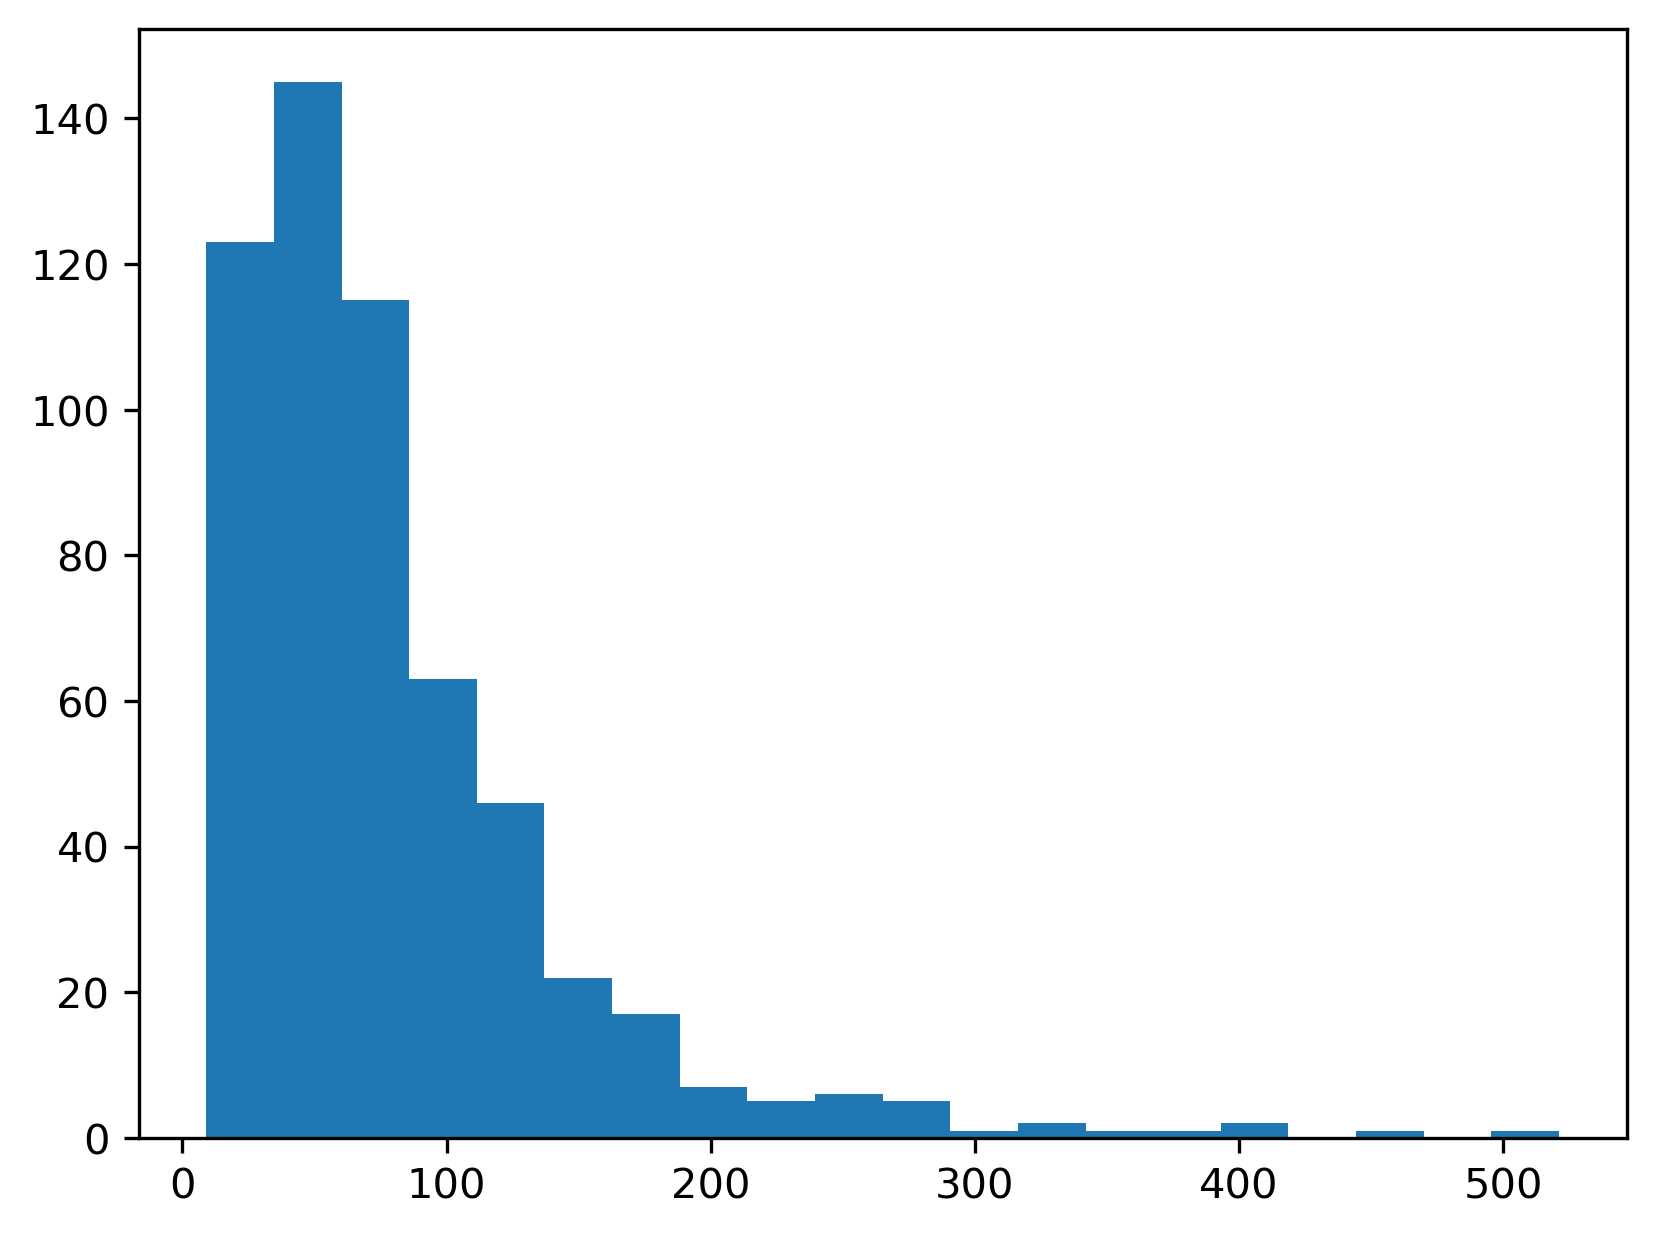

In [211]:
plt.hist(data['Shape_Leng'], 20)

<Axes: xlabel='Landform', ylabel='Count'>

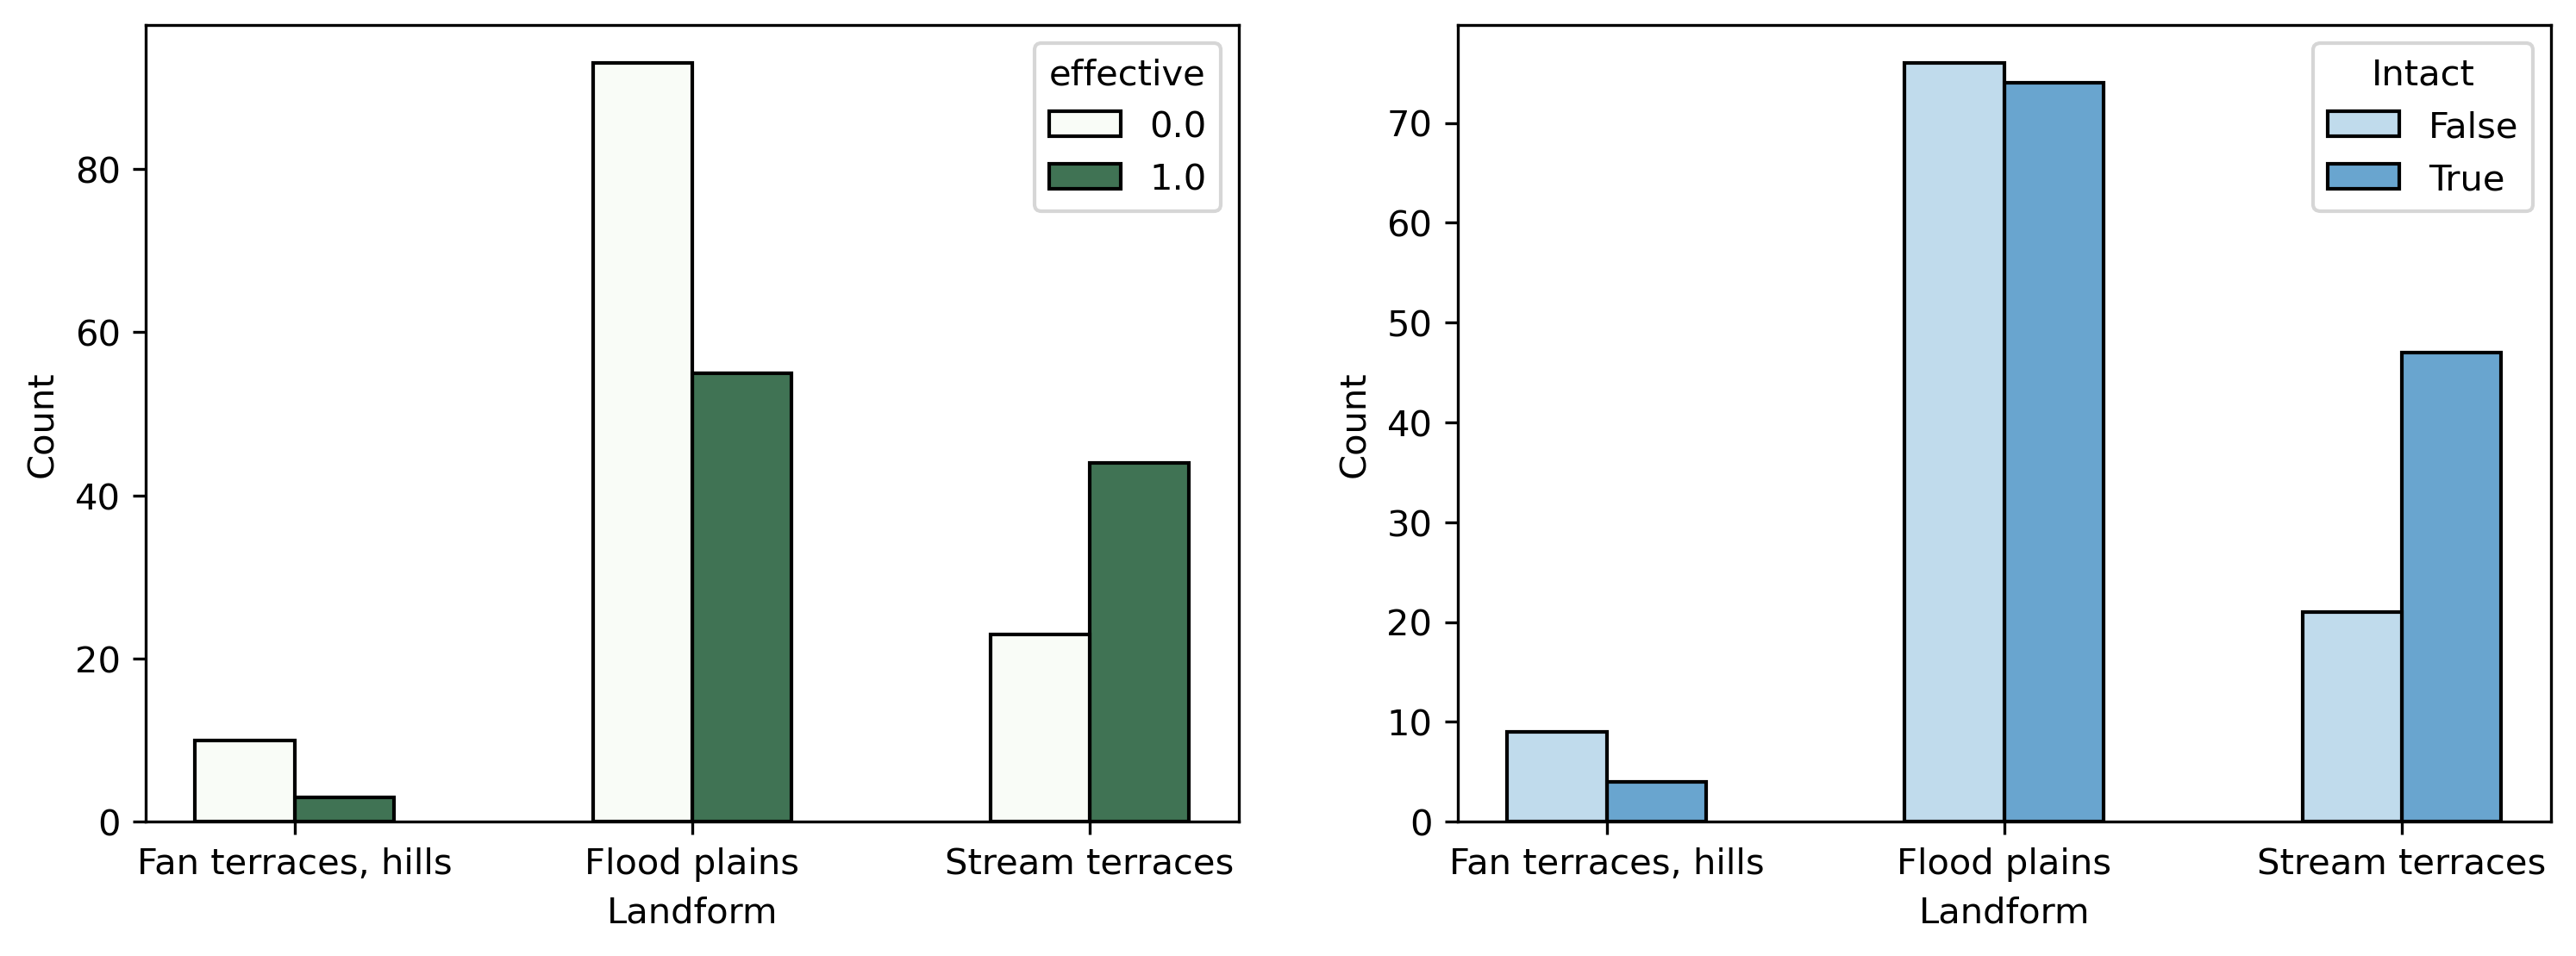

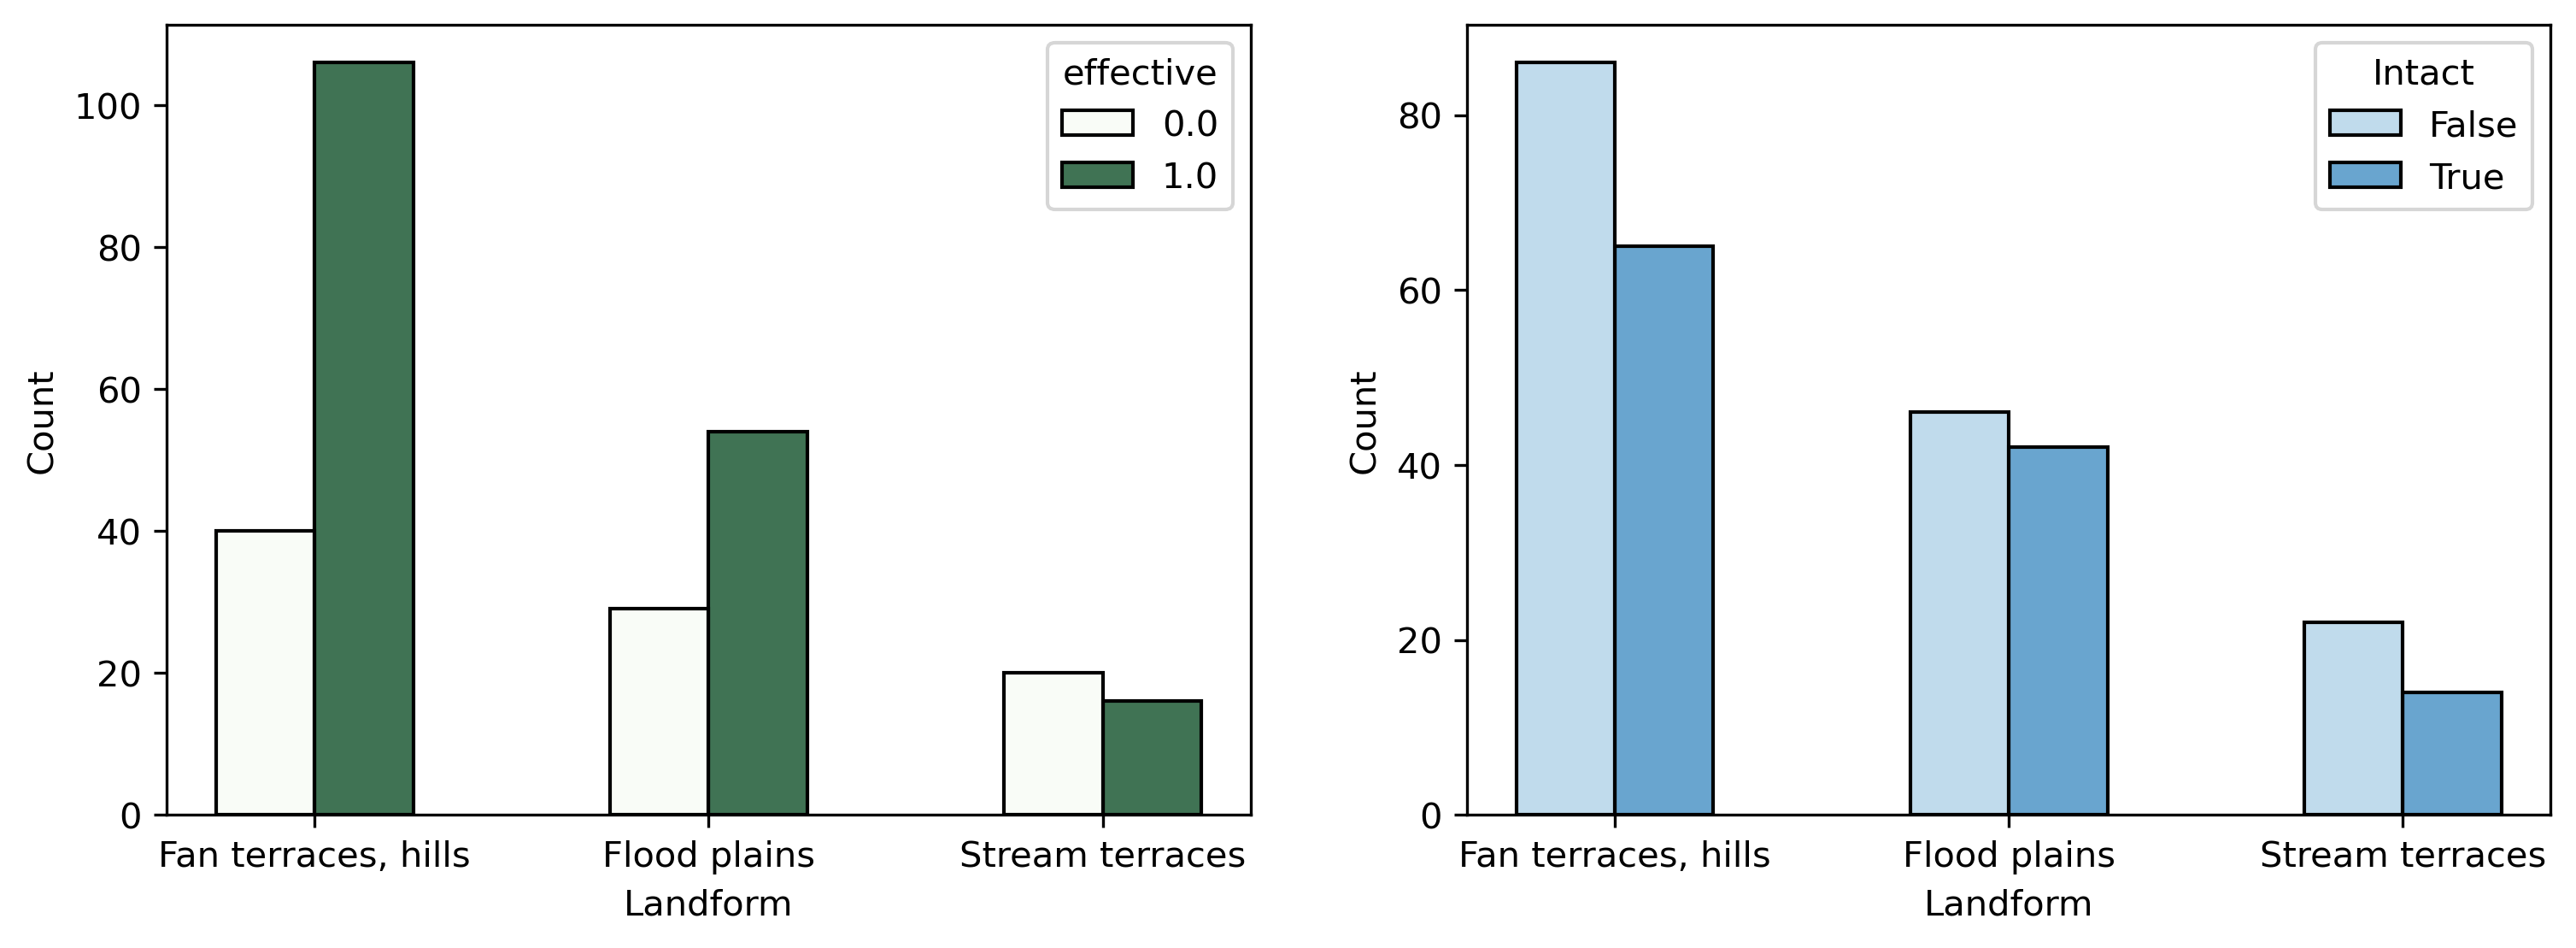

In [212]:
plt.rcParams['figure.dpi'] = 300
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings('ignore')


balanced_data = data.query("Type == 'Berm' and landform == 1")
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.ravel()

sns.histplot (data = balanced_data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = balanced_data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')


balanced_data = data.query("Type == 'Berm' and landform == 0")
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.ravel()

sns.histplot (data = balanced_data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = balanced_data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')



In [213]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.stats import chi2_contingency, fisher_exact, norm

def _auto_positive(series, outcome_name):
    # Determine the "positive" value for a binary series
    v = pd.Series(series.dropna().unique())
    if series.dtype == bool or set(v) <= {True, False}:
        return True
    if set(v) <= {0, 1}:
        return 1
    # try common labels
    if outcome_name.lower().startswith("effect"):
        for cand in ["Effective", "effective", "Yes", "yes", "Positive"]:
            if cand in set(v):
                return cand
    if outcome_name.lower().startswith("intact"):
        for cand in ["Intact", "intact", "Yes", "yes", "Positive"]:
            if cand in set(v):
                return cand
    # fallback: pick the first value
    return v.iloc[0]

def chi2_with_cramers_v(ct: pd.DataFrame):
    chi2, p, dof, expected = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    V = np.sqrt(chi2 / (n * (min(r, k) - 1)))
    return chi2, p, dof, V, expected

def _two_prop_z(count1, n1, count2, n2):
    # pooled two-proportion z test (two-sided)
    p1, p2 = count1/n1, count2/n2
    p_pool = (count1 + count2) / (n1 + n2)
    se = np.sqrt(p_pool * (1 - p_pool) * (1/n1 + 1/n2))
    if se == 0: 
        return 0.0, 1.0, p1 - p2
    z = (p1 - p2) / se
    p = 2 * norm.sf(abs(z))
    return z, p, p1 - p2

def _bh_adjust(pvals):
    pvals = np.asarray(pvals, dtype=float)
    m = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    q = ranked * m / (np.arange(1, m+1))
    q = np.minimum.accumulate(q[::-1])[::-1]
    q = np.minimum(q, 1.0)
    out = np.empty_like(q)
    out[order.argsort()] = q
    return out

def pairwise_by_group(df, group_col, outcome_col, positive=None, fdr_alpha=0.05):
    d = df[[group_col, outcome_col]].dropna()
    if positive is None:
        positive = _auto_positive(d[outcome_col], outcome_col)
    groups = d[group_col].value_counts().index.tolist()
    # per-group counts
    pos = d.groupby(group_col)[outcome_col].apply(lambda x: (x == positive).sum())
    n   = d.groupby(group_col)[outcome_col].size()
    props = (pos / n).rename("proportion").sort_values(ascending=False)

    pairs, p_raw, pinfo = [], [], []
    for a, b in combinations(groups, 2):
        # 2x2 table for Fisher check
        table = np.array([
            [pos[a], n[a]-pos[a]],
            [pos[b], n[b]-pos[b]]
        ])
        use_fisher = (table < 5).any()
        if use_fisher:
            odds, p = fisher_exact(table, alternative="two-sided")
            diff = pos[a]/n[a] - pos[b]/n[b]
            test = "Fisher"
        else:
            z, p, diff = _two_prop_z(pos[a], n[a], pos[b], n[b])
            test = "z"
        pairs.append((a, b))
        p_raw.append(p)
        pinfo.append((diff, test))

    q = _bh_adjust(p_raw) if p_raw else []
    res = pd.DataFrame({
        "group_a": [a for a, _ in pairs],
        "group_b": [b for _, b in pairs],
        "prop_a": [pos[a]/n[a] for a, _ in pairs],
        "prop_b": [pos[b]/n[b] for _, b in pairs],
        "diff_a_minus_b": [di for di, _ in pinfo],
        "test": [te for _, te in pinfo],
        "p_raw": p_raw,
        "q_fdr": q
    }).assign(significant=lambda d: d["q_fdr"] < fdr_alpha).sort_values("q_fdr")
    return res, props

def analyze_outcome(df, group_col, outcome_col, positive=None, fdr_alpha=0.05):
    # contingency Landform x outcome (2 cols assumed)
    ct = pd.crosstab(df[group_col], df[outcome_col])
    chi2, p, dof, V, expected = chi2_with_cramers_v(ct)
    res_pairs, props = pairwise_by_group(df, group_col, outcome_col, positive, fdr_alpha)
    return {
        "global": {"chi2": chi2, "p_value": p, "dof": dof, "cramers_v": V},
        "pairwise": res_pairs,
        "proportions": props
    }

# ===== Run for your two outcomes =====
out_eff = analyze_outcome(data, group_col="Landform", outcome_col="Effective", positive=None, fdr_alpha=0.05)
out_int = analyze_outcome(data, group_col="Landform", outcome_col="Intact",    positive=None, fdr_alpha=0.05)

print("\n=== Stability (Effective) vs Landform ===")
print("Global χ² p-value:", f"{out_eff['global']['p_value']:.3g}", 
      "| Cramér’s V:", f"{out_eff['global']['cramers_v']:.3f}")
print("\nProportion Effective by Landform:")
print(out_eff["proportions"].round(3))
print("\nSignificant pairwise differences (FDR q<0.05):")
print(out_eff["pairwise"][out_eff["pairwise"]["significant"]]
      .assign(prop_a=lambda d: d["prop_a"].round(3),
              prop_b=lambda d: d["prop_b"].round(3),
              diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3))
      .reset_index(drop=True))

print("\n=== Intactness (Intact) vs Landform ===")
print("Global χ² p-value:", f"{out_int['global']['p_value']:.3g}", 
      "| Cramér’s V:", f"{out_int['global']['cramers_v']:.3f}")
print("\nProportion Intact by Landform:")
print(out_int["proportions"].round(3))
print("\nSignificant pairwise differences (FDR q<0.05):")
print(out_int["pairwise"][out_int["pairwise"]["significant"]]
      .assign(prop_a=lambda d: d["prop_a"].round(3),
              prop_b=lambda d: d["prop_b"].round(3),
              diff_a_minus_b=lambda d: d["diff_a_minus_b"].round(3))
      .reset_index(drop=True))



=== Stability (Effective) vs Landform ===
Global χ² p-value: 0.000123 | Cramér’s V: 0.181

Proportion Effective by Landform:
Landform
Fan terraces, hills    0.677
Stream terraces        0.586
Flood plains           0.467
Name: proportion, dtype: float64

Significant pairwise differences (FDR q<0.05):
        group_a              group_b  prop_a  prop_b  diff_a_minus_b test  \
0  Flood plains  Fan terraces, hills   0.467   0.677          -0.209    z   
1  Flood plains      Stream terraces   0.467   0.586          -0.118    z   

      p_raw     q_fdr  significant  
0  0.000030  0.000089         True  
1  0.025475  0.038213         True  

=== Intactness (Intact) vs Landform ===
Global χ² p-value: 0.00314 | Cramér’s V: 0.143

Proportion Intact by Landform:
Landform
Stream terraces        0.624
Flood plains           0.502
Fan terraces, hills    0.432
Name: proportion, dtype: float64

Significant pairwise differences (FDR q<0.05):
               group_a          group_b  prop_a  prop_b  

Text(0.5, 0.98, 'Channel')

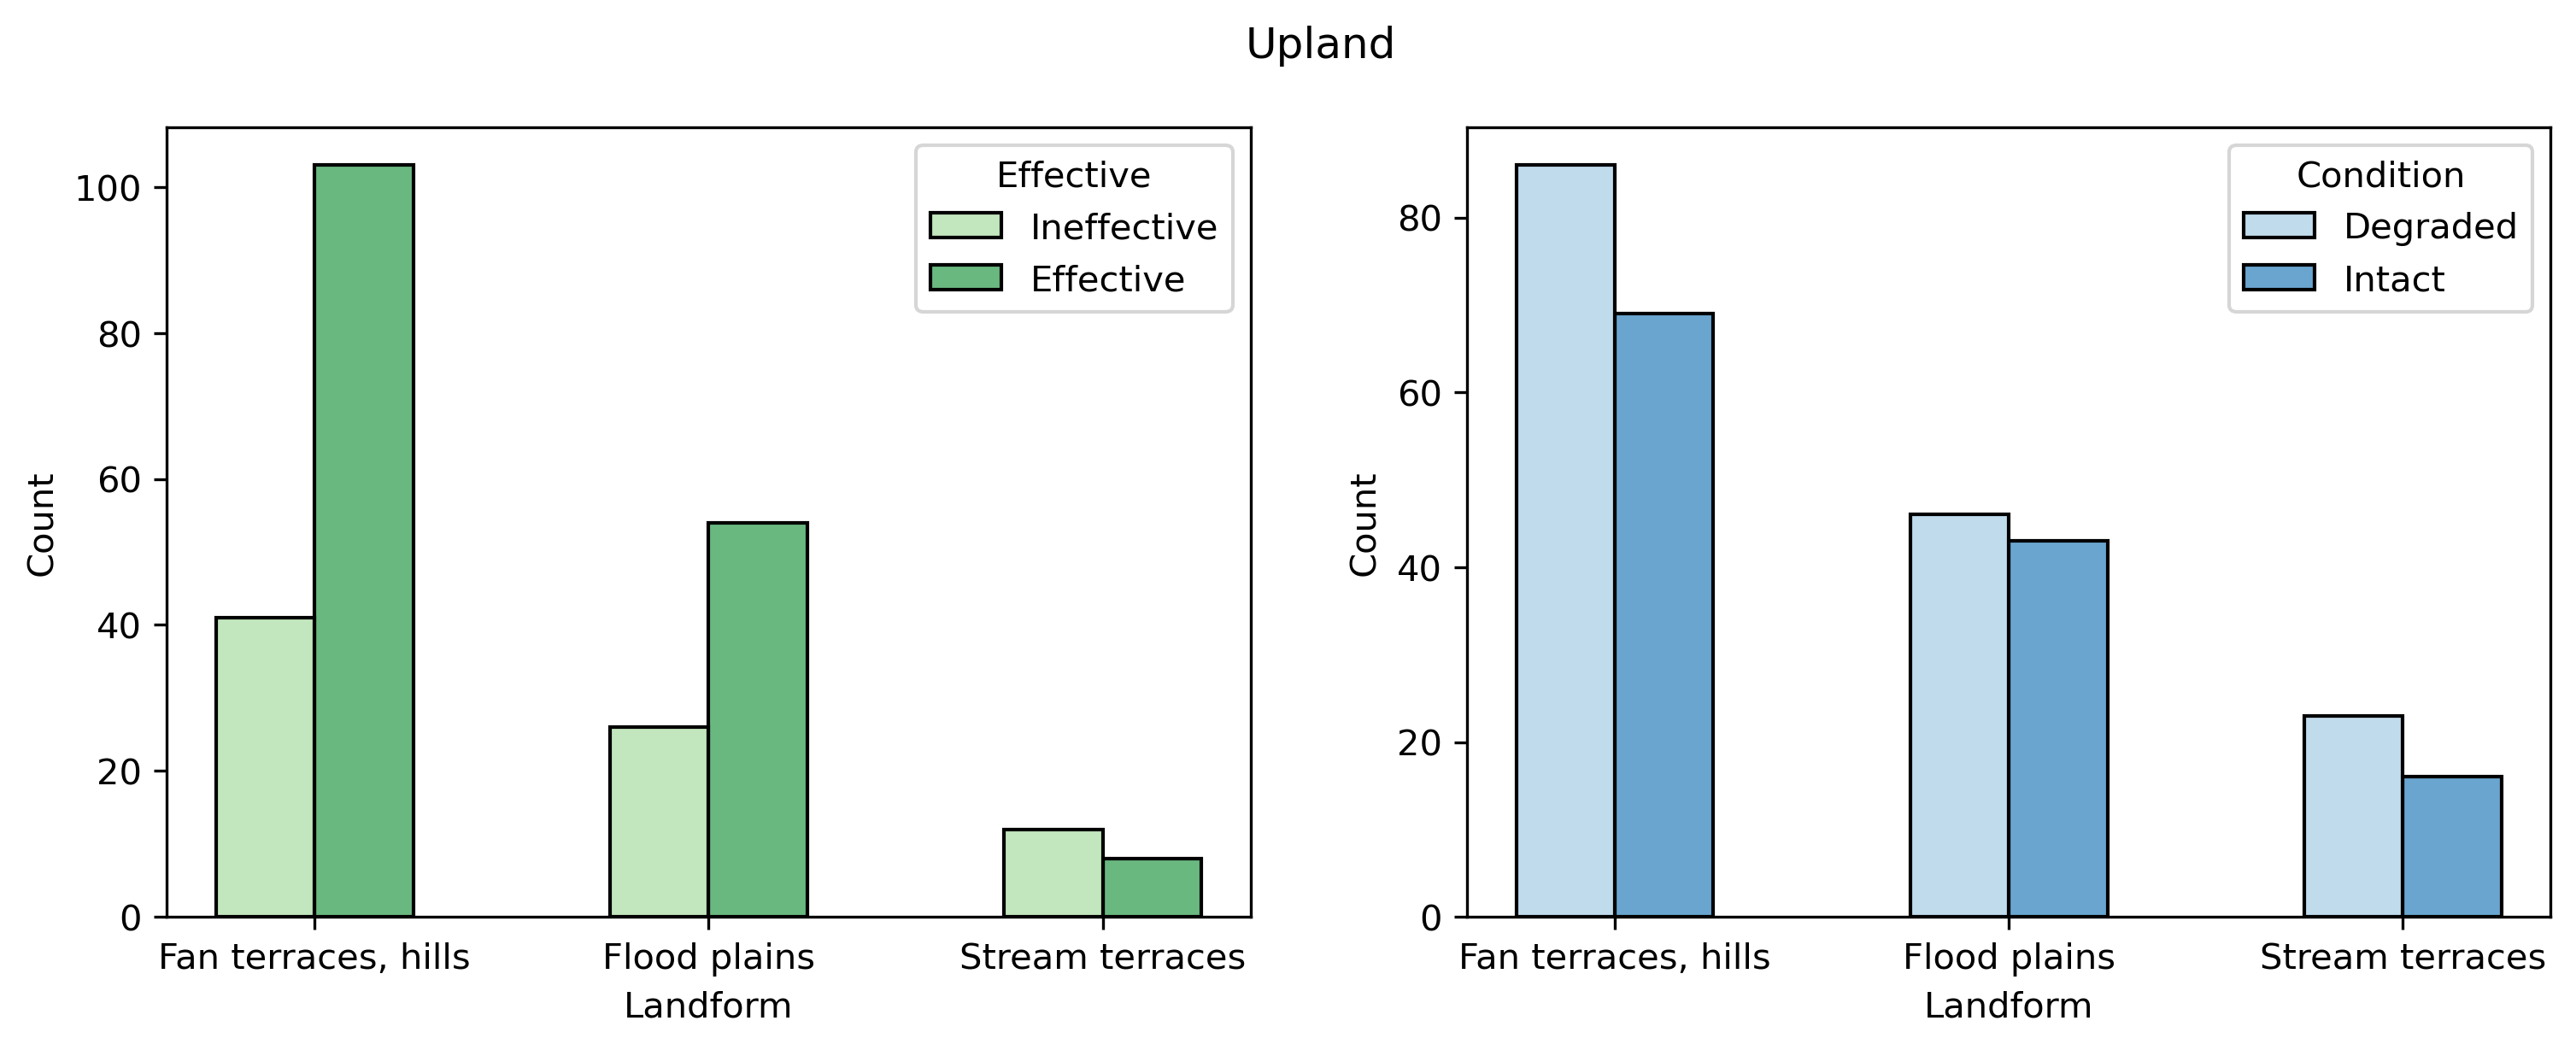

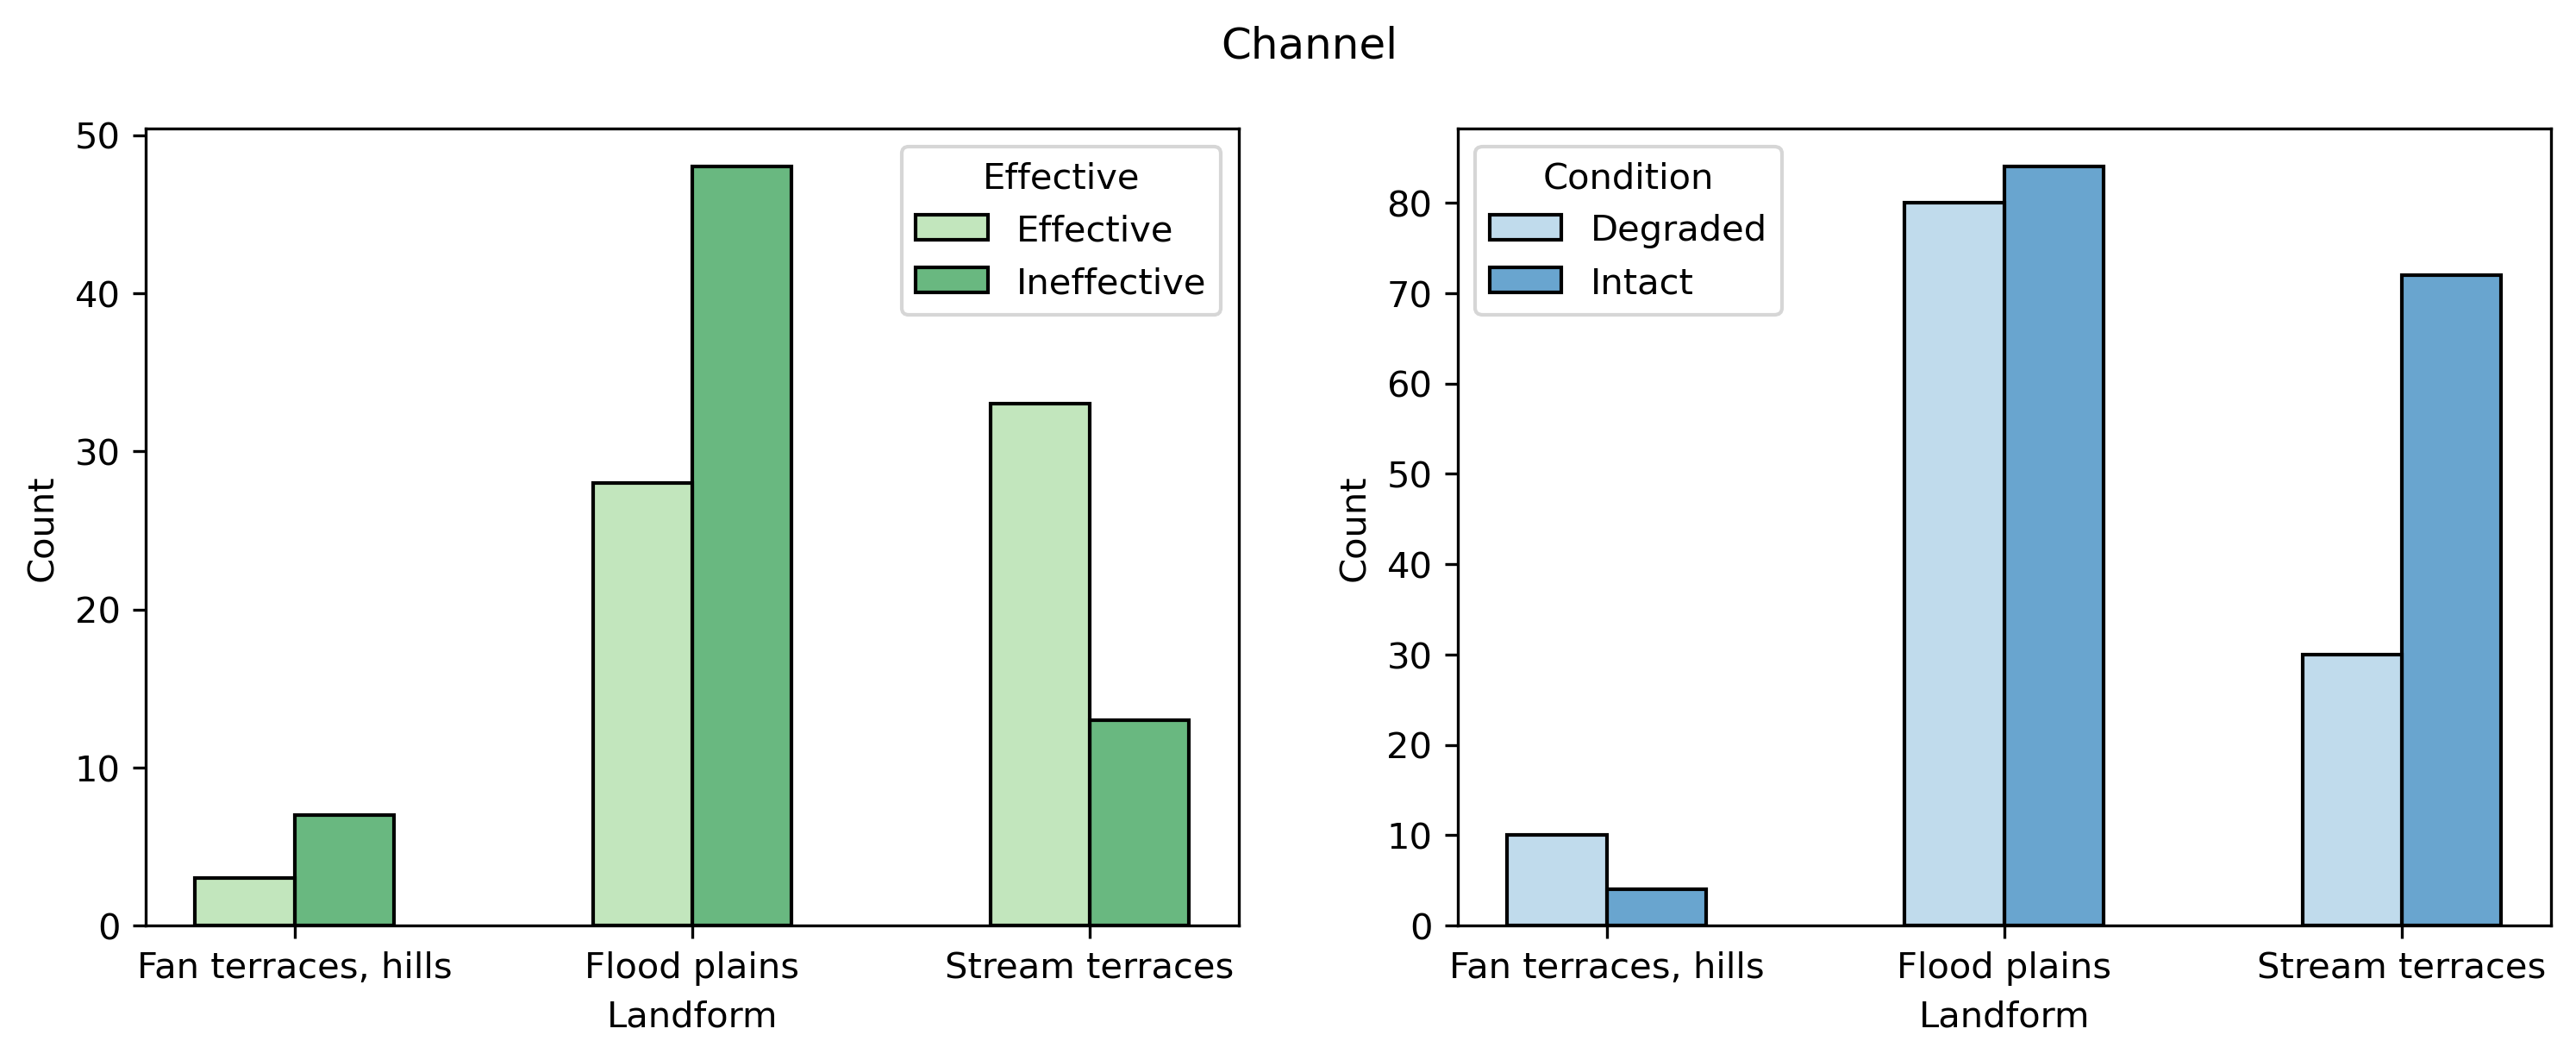

In [250]:
plt.rcParams['figure.dpi'] = 300
import matplotlib.pylab as plt
import warnings
warnings.filterwarnings('ignore')


balanced_data = data.copy()
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.ravel()

c = sns.histplot (data = data.sort_values("Landform").query("landform == 0")[((data['zU_60'] - data['zD_60']) > 0.5)]
                  , x = 'Landform' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')

sns.histplot (data = data.sort_values("Landform").query("landform == 0"), x = 'Landform' ,  
              hue ='Condition',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')

plt.suptitle("Upland")

fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.ravel()

c = sns.histplot (data = data.sort_values("Landform").query("landform == 1")[((data['zU_60'] - data['zD_60']) >  0.5)],
                  x = 'Landform' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')

sns.histplot (data = data.sort_values("Landform").query("landform == 1"), x = 'Landform' ,  
              hue ='Condition',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')

plt.suptitle("Channel")

(556, 67) (563, 67)


<Axes: xlabel='Landform', ylabel='Count'>

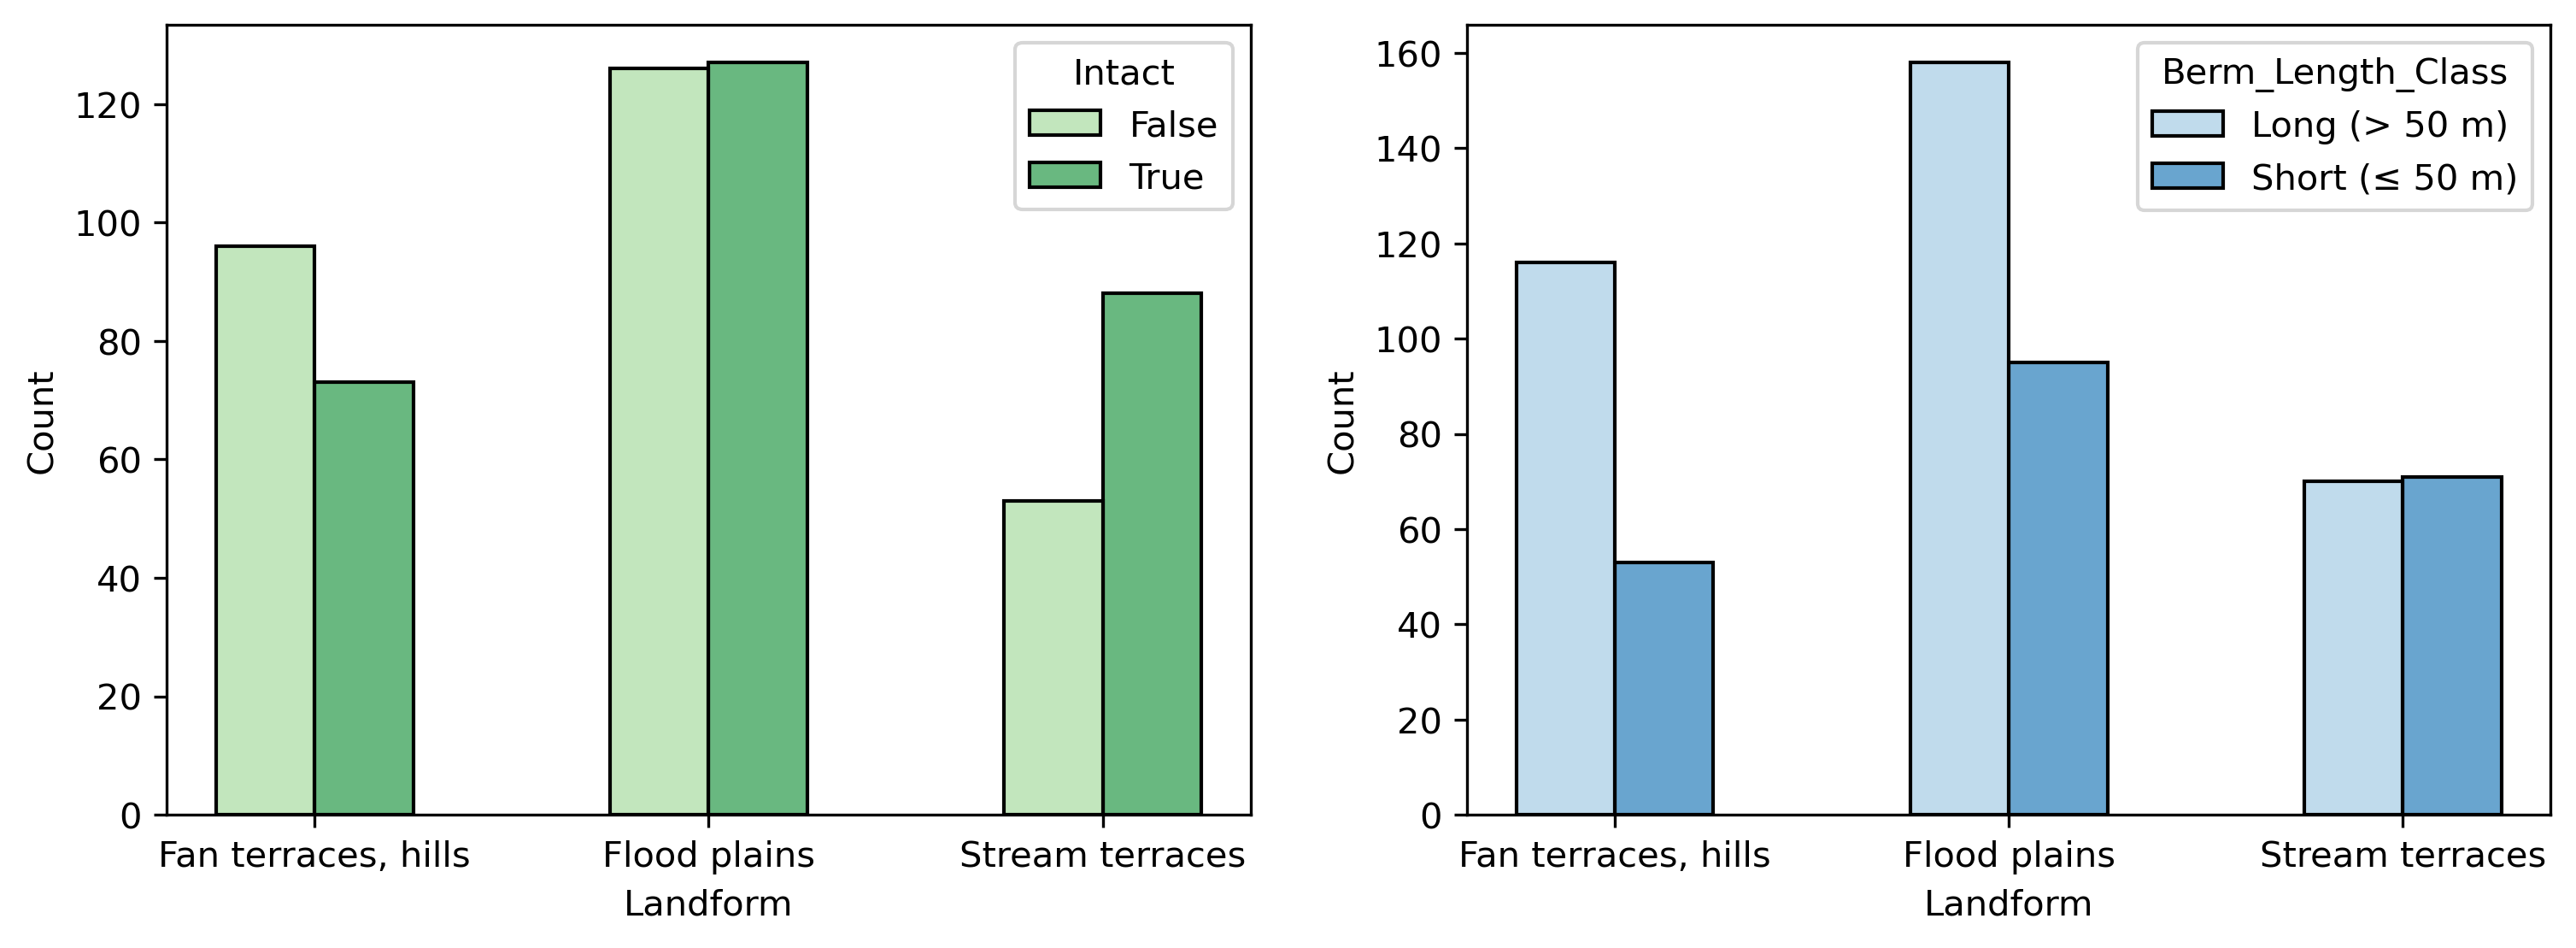

In [95]:

balanced_data = data.copy()
balanced_data = data[data.Structure_.isna()]
print (balanced_data.shape, data.shape)
fig, axes = plt.subplots(1, 2, figsize = (12,4))
axes = axes.ravel()

sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='Intact',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Landform' ,  
              hue ='Berm_Length_Class',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')





In [73]:
data['Structure_'].unique()

array([nan, 'Watercontrol', 'Rockgabion'], dtype=object)

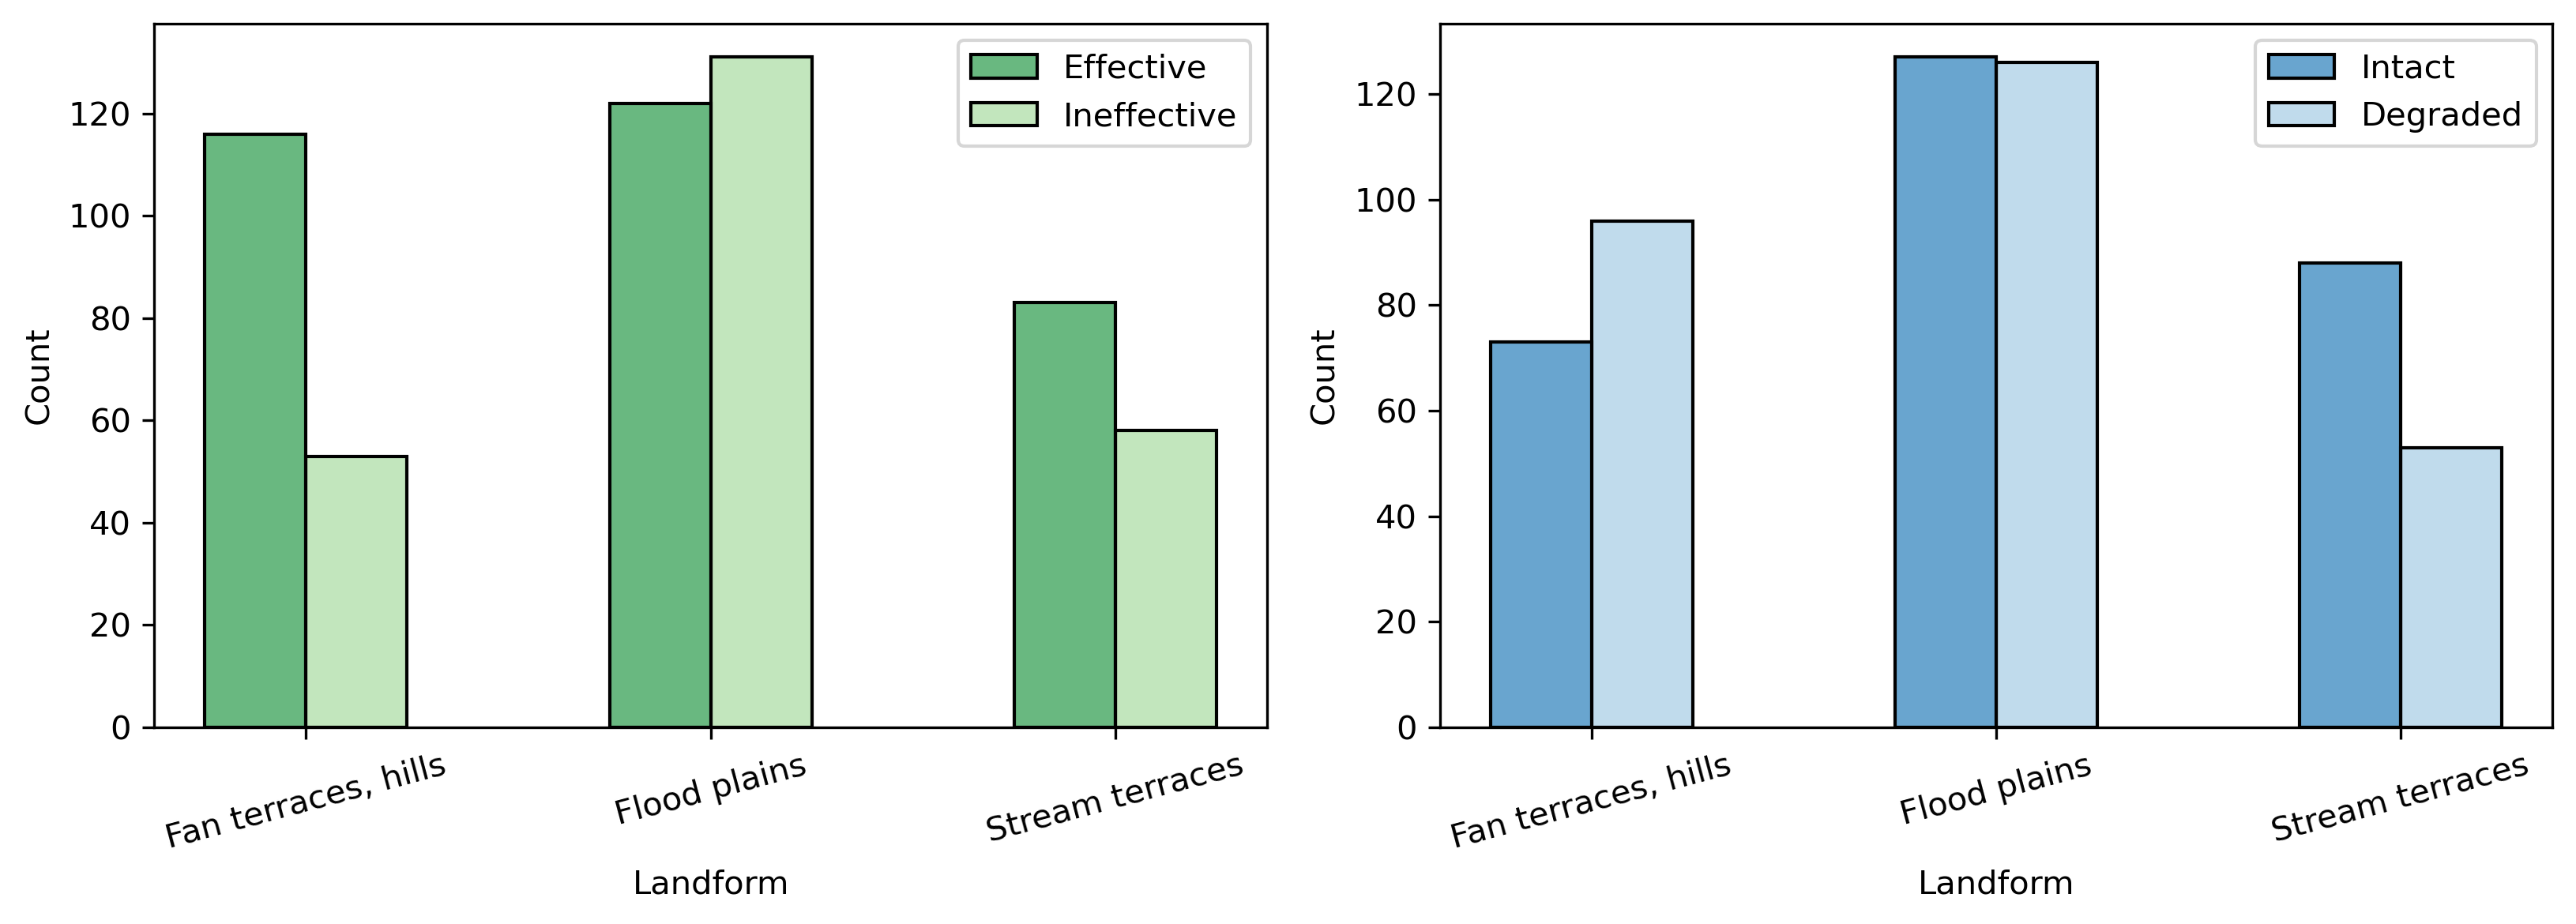

In [70]:

plot_df = data.copy()
plot_df["Effective_lbl"] = pd.Categorical(
    np.where(plot_df["Effective"].astype(bool), "Effective", "Ineffective"),
    categories=["Effective", "Ineffective"], ordered=True
)
plot_df["Intact_lbl"] = pd.Categorical(
    np.where(plot_df["Intact"].astype(bool), "Intact", "Degraded"),
    categories=["Intact", "Degraded"], ordered=True
)

greens = sns.color_palette("Greens", 2)
blues  = sns.color_palette("Blues", 2)
palette_eff = {"Effective": greens[1], "Ineffective": greens[0]}
palette_int = {"Intact": blues[1], "Degraded": blues[0]}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# Stability
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Effective_lbl", hue_order=["Effective", "Ineffective"],
    multiple="dodge", shrink=0.5, stat="count", palette=palette_eff,
    ax=axes[0], legend=True
)

# Intactness
sns.histplot(
    data=plot_df.sort_values("Landform"),
    x="Landform", hue="Intact_lbl", hue_order=["Intact", "Degraded"],
    multiple="dodge", shrink=0.5, stat="count", palette=palette_int,
    ax=axes[1], legend=True
)

# Title/position legends the seaborn way (no manual ax.legend() call)
try:
    sns.move_legend(axes[0], "upper right", title="", frameon=True)
    sns.move_legend(axes[1], "upper right", title="", frameon=True)
except Exception:
    # Fallback for older seaborn: retitle existing legends if present
    if axes[0].legend_ is not None: axes[0].legend_.set_title("Stability")
    if axes[1].legend_ is not None: axes[1].legend_.set_title("Intactness")

for ax in axes:
    ax.set_xlabel("Landform")
    ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=15)

plt.tight_layout()


<Axes: xlabel='Soil_Development', ylabel='Count'>

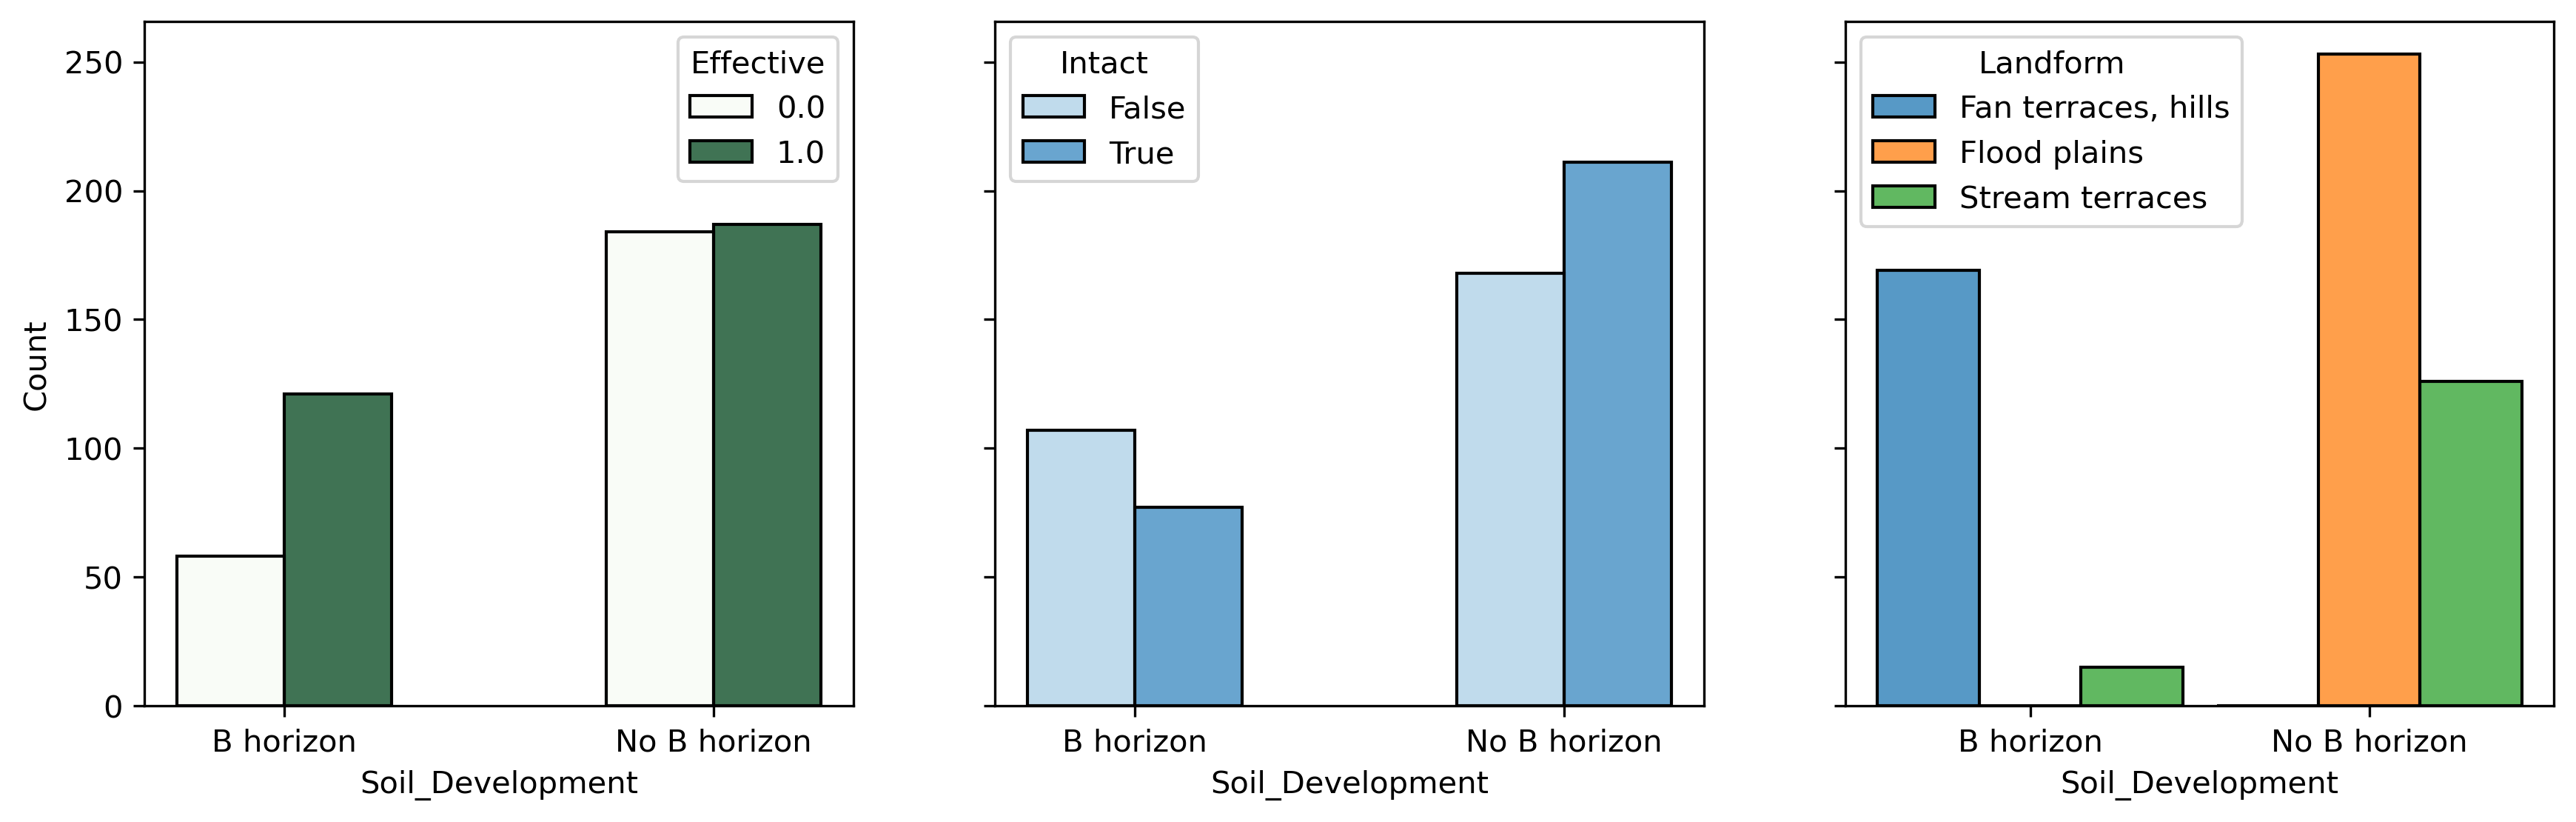

In [48]:

fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Soil_Development",ascending =  True), x = 'Soil_Development' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Soil_Development",ascending =  True), x = 'Soil_Development' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')


sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Soil_Development' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])



In [ ]:

fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Berm_Length_Class",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Berm_Length_Class",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')


sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Berm_Length_Class' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])



In [ ]:

fig, axes = plt.subplots(1, 3, figsize = (14,4), sharey = True)
axes = axes.ravel()

sns.histplot (data = data.sort_values("Slope_Class",ascending =  True), x = 'Slope_Class' ,  
              hue ='Effective',ax= axes[0], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Greens')


sns.histplot (data = data.sort_values("Slope_Class",ascending =  True), x = 'Slope_Class' ,  
              hue ='Intact',ax= axes[1], stat = 'count',
              shrink = 0.5, multiple ='dodge', palette = 'Blues')


sns.histplot (data = data.sort_values("Landform",ascending =  True), x = 'Slope_Class' ,  
              hue ='Landform',ax= axes[2], stat = 'count',
              shrink = 0.9, multiple ='dodge', palette = ['C0', 'C1', 'C2'])



In [ ]:

# fig, axes = plt.subplots(2, 2, figsize = (12,8))
# axes = axes.ravel()
# sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
#               hue ='Berm_Length_Class',ax= axes[0], stat = 'count',
#               shrink = 0.5, multiple ='dodge', palette = 'Greens')


# sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
#               hue ='Slope_Class',ax= axes[1], stat = 'count',
#               shrink = 0.5, multiple ='dodge', palette = 'Greens')


# sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
#               hue ='High_Clay',ax= axes[2], stat = 'count',
#               shrink = 0.5, multiple ='dodge', palette = 'Greens')

# sns.histplot (data = data.sort_values("Landform", ascending =  True), x = 'Landform' , 
#               hue ='Soil_Development',ax= axes[3], stat = 'count',
#               shrink = 0.6, multiple ='dodge', palette = 'Greens')


# Fan terraces are more effective because steeper, lower clay
# Floodplains less effective because gentle slopes, high clay
# Stream terraces more effective because 

# different reasons, design criteria, inherent differnces.
# characteristics take away ..
 